<a href="https://colab.research.google.com/github/maruson08/GNN_Outlier_Remover/blob/main/GNN_Outlier_Remover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install koreanize_matplotlib

In [ ]:
import koreanize_matplotlib

=== 실제 이미지 데이터를 이용한 GNN 이상치 탐지 ===
1. 이미지 데이터 로드...
폴더 'imgData/mini_final'에서 500개의 이미지를 발견했습니다.
성공적으로 500개의 이미지를 로드했습니다.
단일 폴더 모드: 모든 이미지를 정상으로 가정합니다.
이상치는 재구성 오차가 높은 상위 10%로 설정됩니다.
총 500개의 이미지를 로드했습니다.
정상: 500개, 이상: 0개
2. 이미지를 그래프로 변환...
진행률: 1/500
진행률: 11/500
진행률: 21/500
진행률: 31/500
진행률: 41/500
진행률: 51/500
진행률: 61/500
진행률: 71/500
진행률: 81/500
진행률: 91/500
진행률: 101/500
진행률: 111/500
진행률: 121/500
진행률: 131/500
진행률: 141/500
진행률: 151/500
진행률: 161/500
진행률: 171/500
진행률: 181/500
진행률: 191/500
진행률: 201/500
진행률: 211/500
진행률: 221/500
진행률: 231/500
진행률: 241/500
진행률: 251/500
진행률: 261/500
진행률: 271/500
진행률: 281/500
진행률: 291/500
진행률: 301/500
진행률: 311/500
진행률: 321/500
진행률: 331/500
진행률: 341/500
진행률: 351/500
진행률: 361/500
진행률: 371/500
진행률: 381/500
진행률: 391/500
진행률: 401/500
진행률: 411/500
진행률: 421/500
진행률: 431/500
진행률: 441/500
진행률: 451/500
진행률: 461/500
진행률: 471/500
진행률: 481/500
진행률: 491/500
Train dataset: 400 images (Normal data)
Test dataset: 100 images
특성 차원: 20
3. 모델 훈련...
Epoch [10/50], Loss: 0.4268
Epoch 

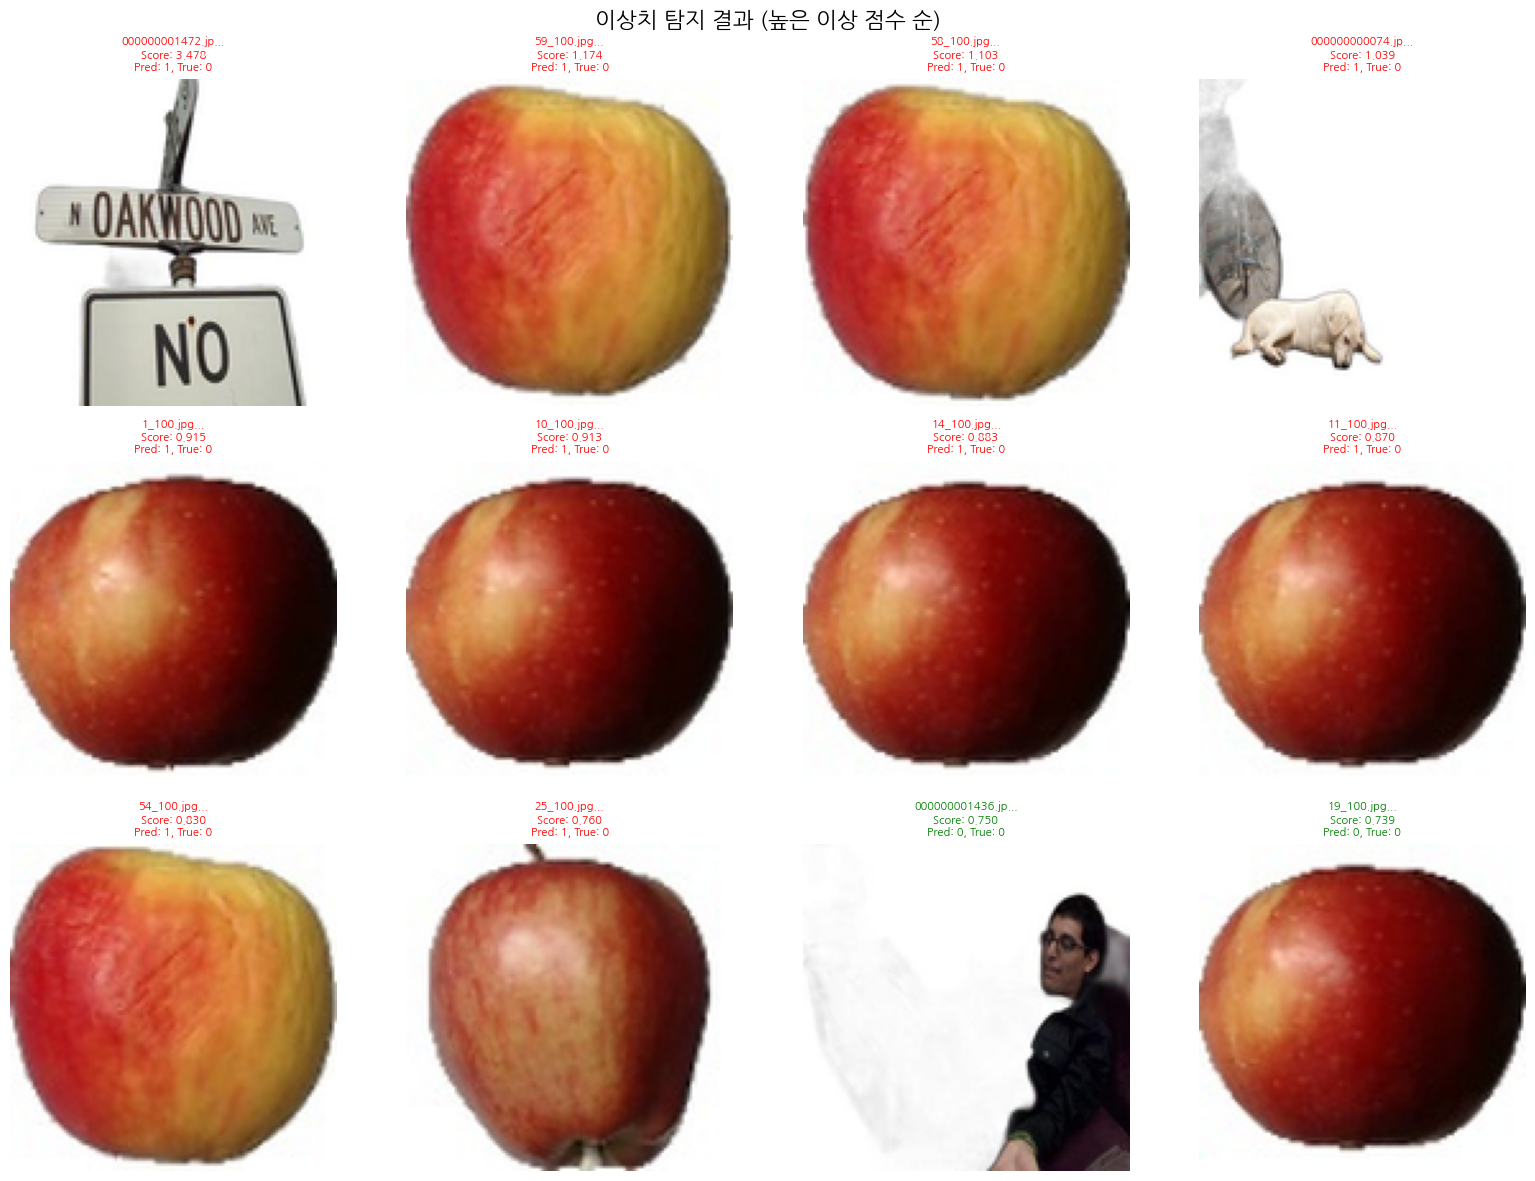

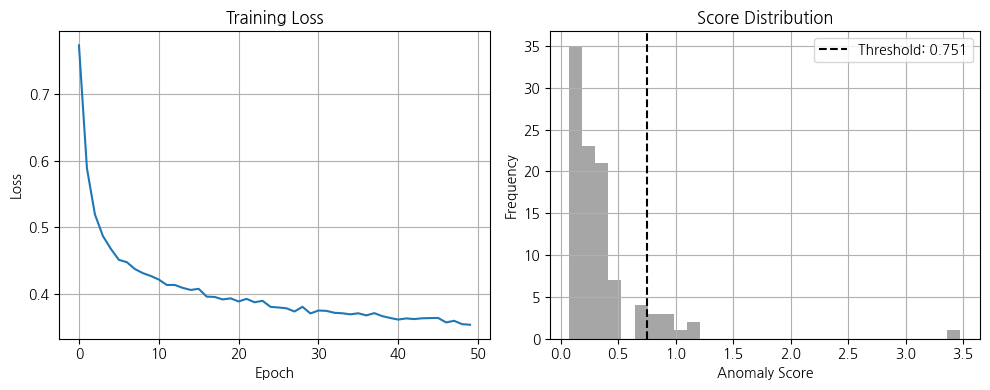


=== Finish ===


{'summary': {'total_images': 100,
  'normal_detected': 90,
  'anomaly_detected': 10,
  'threshold': 0.7505071759223938},
 'detailed_results': [{'filename': '000000001472.jpg',
   'anomaly_score': 3.4778130054473877,
   'prediction': 'anomaly',
   'true_label': 'normal'},
  {'filename': '59_100.jpg',
   'anomaly_score': 1.1738468408584595,
   'prediction': 'anomaly',
   'true_label': 'normal'},
  {'filename': '58_100.jpg',
   'anomaly_score': 1.1027165651321411,
   'prediction': 'anomaly',
   'true_label': 'normal'},
  {'filename': '000000000074.jpg',
   'anomaly_score': 1.0390896797180176,
   'prediction': 'anomaly',
   'true_label': 'normal'},
  {'filename': '1_100.jpg',
   'anomaly_score': 0.9152055382728577,
   'prediction': 'anomaly',
   'true_label': 'normal'},
  {'filename': '10_100.jpg',
   'anomaly_score': 0.913083553314209,
   'prediction': 'anomaly',
   'true_label': 'normal'},
  {'filename': '14_100.jpg',
   'anomaly_score': 0.8827463984489441,
   'prediction': 'anomaly',
  

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import cv2
from typing import List, Tuple, Dict
import warnings
import os
import glob
from PIL import Image
import json
warnings.filterwarnings('ignore')

class Node:
    """그래프 노드 클래스"""
    def __init__(self, node_id: int, features: np.ndarray, position: Tuple[int, int] = None):
        self.id = node_id
        self.features = features
        self.position = position  # 이미지에서의 위치 (row, col)
        self.neighbors = []
        self.edge_weights = {}

    def add_neighbor(self, neighbor_id: int, weight: float = 1.0):
        """이웃 노드 추가"""
        if neighbor_id not in self.neighbors:
            self.neighbors.append(neighbor_id)
            self.edge_weights[neighbor_id] = weight

    def get_feature_dim(self):
        return len(self.features)

class Graph:
    """그래프 클래스"""
    def __init__(self):
        self.nodes = {}
        self.num_nodes = 0
        self.adjacency_matrix = None
        self.feature_matrix = None

    def add_node(self, node: Node):
        """노드 추가"""
        self.nodes[node.id] = node
        self.num_nodes += 1

    def add_edge(self, node1_id: int, node2_id: int, weight: float = 1.0):
        """엣지 추가 (양방향)"""
        if node1_id in self.nodes and node2_id in self.nodes:
            self.nodes[node1_id].add_neighbor(node2_id, weight)
            self.nodes[node2_id].add_neighbor(node1_id, weight)

    def build_matrices(self):
        """인접 행렬과 특성 행렬 구성"""
        if self.num_nodes == 0:
            return

        # 특성 행렬 구성
        feature_dim = self.nodes[0].get_feature_dim()
        self.feature_matrix = np.zeros((self.num_nodes, feature_dim))

        for node_id, node in self.nodes.items():
            self.feature_matrix[node_id] = node.features

        # 인접 행렬 구성
        self.adjacency_matrix = np.zeros((self.num_nodes, self.num_nodes))

        for node_id, node in self.nodes.items():
            for neighbor_id in node.neighbors:
                weight = node.edge_weights[neighbor_id]
                self.adjacency_matrix[node_id][neighbor_id] = weight

    def get_degree_matrix(self):
        """Degree 행렬 반환"""
        if self.adjacency_matrix is None:
            self.build_matrices()

        degree_matrix = np.diag(np.sum(self.adjacency_matrix, axis=1))
        return degree_matrix

    def get_normalized_adjacency(self):
        """정규화된 인접 행렬 반환 (D^(-1/2) * A * D^(-1/2))"""
        if self.adjacency_matrix is None:
            self.build_matrices()

        # Self-loop 추가
        A = self.adjacency_matrix + np.eye(self.num_nodes)

        # Degree 계산
        D = np.sum(A, axis=1)
        D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-6))  # 0으로 나누기 방지

        # 정규화
        A_norm = D_inv_sqrt @ A @ D_inv_sqrt
        return A_norm

class ImageToGraph:
    """이미지를 그래프로 변환하는 클래스"""
    def __init__(self, patch_size: int = 8, overlap: int = 4):
        self.patch_size = patch_size
        self.overlap = overlap

    def extract_patches(self, image: np.ndarray) -> List[Tuple[np.ndarray, Tuple[int, int]]]:
        """이미지에서 패치 추출"""
        patches = []
        h, w = image.shape[:2]

        step = self.patch_size - self.overlap

        for i in range(0, h - self.patch_size + 1, step):
            for j in range(0, w - self.patch_size + 1, step):
                patch = image[i:i+self.patch_size, j:j+self.patch_size]
                patches.append((patch, (i, j)))

        return patches

    def extract_features(self, patch: np.ndarray) -> np.ndarray:
        """패치에서 특성 추출"""
        # 그레이스케일 변환
        if len(patch.shape) == 3:
            gray_patch = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
        else:
            gray_patch = patch

        # 통계적 특성
        mean_val = np.mean(gray_patch)
        std_val = np.std(gray_patch)

        # 히스토그램 특성
        hist, _ = np.histogram(gray_patch.flatten(), bins=16, range=(0, 256))
        hist = hist / (hist.sum() + 1e-6)  # 정규화

        # 그래디언트 특성
        grad_x = cv2.Sobel(gray_patch, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray_patch, cv2.CV_64F, 0, 1, ksize=3)
        grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
        grad_mean = np.mean(grad_magnitude)
        grad_std = np.std(grad_magnitude)

        # 특성 결합
        features = np.concatenate([
            [mean_val, std_val, grad_mean, grad_std],
            hist
        ])

        return features

    def calculate_patch_similarity(self, patch1: np.ndarray, patch2: np.ndarray) -> float:
        """두 패치 간의 유사도 계산"""
        # 정규화된 상관계수 사용
        patch1_flat = patch1.flatten().astype(np.float32)
        patch2_flat = patch2.flatten().astype(np.float32)

        # 평균 제거
        patch1_flat = patch1_flat - np.mean(patch1_flat)
        patch2_flat = patch2_flat - np.mean(patch2_flat)

        # 상관계수 계산
        numerator = np.dot(patch1_flat, patch2_flat)
        denominator = np.sqrt(np.sum(patch1_flat**2) * np.sum(patch2_flat**2)) + 1e-6

        correlation = numerator / denominator
        return max(0, correlation)  # 음수 상관계수는 0으로 처리

    def convert_to_graph(self, image: np.ndarray, k_neighbors: int = 8) -> Graph:
        """이미지를 그래프로 변환"""
        graph = Graph()

        # 패치 추출
        patches = self.extract_patches(image)

        # 노드 생성
        for node_id, (patch, position) in enumerate(patches):
            features = self.extract_features(patch)
            node = Node(node_id, features, position)
            graph.add_node(node)

        # 엣지 생성 (k-nearest neighbors)
        for i, (patch_i, pos_i) in enumerate(patches):
            similarities = []

            for j, (patch_j, pos_j) in enumerate(patches):
                if i != j:
                    # 공간적 거리 고려
                    spatial_dist = np.sqrt((pos_i[0] - pos_j[0])**2 + (pos_i[1] - pos_j[1])**2)

                    # 너무 먼 패치는 연결하지 않음
                    if spatial_dist < self.patch_size * 3:
                        similarity = self.calculate_patch_similarity(patch_i, patch_j)
                        similarities.append((j, similarity, spatial_dist))

            # 유사도 기준으로 정렬하고 상위 k개 선택
            similarities.sort(key=lambda x: x[1], reverse=True)

            for neighbor_id, similarity, spatial_dist in similarities[:k_neighbors]:
                if similarity > 0.1:  # 임계값 설정
                    weight = similarity / (1 + spatial_dist * 0.1)  # 거리에 따른 가중치 조정
                    graph.add_edge(i, neighbor_id, weight)

        graph.build_matrices()
        return graph

class GCNLayer(nn.Module):
    """Graph Convolutional Network 레이어"""
    def __init__(self, input_dim: int, output_dim: int):
        super(GCNLayer, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x: torch.Tensor, adj_matrix: torch.Tensor):
        # GCN 연산: A * X * W
        x = torch.matmul(adj_matrix, x)
        x = self.linear(x)
        x = self.activation(x)
        x = self.dropout(x)
        return x

class GNNAnomalyDetector(nn.Module):
    """GNN 기반 이상치 탐지 모델"""
    def __init__(self, input_dim: int, hidden_dims: List[int] = [64, 32, 16]):
        super(GNNAnomalyDetector, self).__init__()

        # GCN 레이어들
        self.gcn_layers = nn.ModuleList()

        # 첫 번째 레이어
        self.gcn_layers.append(GCNLayer(input_dim, hidden_dims[0]))

        # 나머지 레이어들
        for i in range(1, len(hidden_dims)):
            self.gcn_layers.append(GCNLayer(hidden_dims[i-1], hidden_dims[i]))

        # 재구성을 위한 디코더
        self.decoder = nn.ModuleList()
        decoder_dims = hidden_dims[::-1] + [input_dim]  # 역순으로 디코더 구성

        for i in range(len(decoder_dims) - 1):
            self.decoder.append(nn.Linear(decoder_dims[i], decoder_dims[i+1]))

    def forward(self, x: torch.Tensor, adj_matrix: torch.Tensor):
        # 인코더 (GCN 레이어들)
        encoded = x
        for gcn_layer in self.gcn_layers:
            encoded = gcn_layer(encoded, adj_matrix)

        # 디코더 (재구성)
        decoded = encoded
        for i, decoder_layer in enumerate(self.decoder):
            decoded = decoder_layer(decoded)
            if i < len(self.decoder) - 1:  # 마지막 레이어가 아니면 활성화 함수 적용
                decoded = torch.relu(decoded)

        return encoded, decoded

class GraphDataset(Dataset):
    """그래프 데이터셋 클래스"""
    def __init__(self, graphs: List[Graph], labels: List[int]):
        self.graphs = graphs
        self.labels = labels

        # 특성 정규화
        self.scaler = StandardScaler()
        all_features = np.vstack([graph.feature_matrix for graph in graphs])
        self.scaler.fit(all_features)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        graph = self.graphs[idx]
        label = self.labels[idx]

        # 특성 정규화
        features = self.scaler.transform(graph.feature_matrix)
        adj_matrix = graph.get_normalized_adjacency()

        return {
            'features': torch.FloatTensor(features),
            'adj_matrix': torch.FloatTensor(adj_matrix),
            'label': torch.LongTensor([label])
        }

def generate_synthetic_images(num_normal: int = 100, num_anomaly: int = 20,
                            image_size: Tuple[int, int] = (64, 64)) -> Tuple[List[np.ndarray], List[int]]:
    """합성 이미지 데이터 생성"""
    images = []
    labels = []

    # 정상 이미지 생성 (자연스러운 패턴)
    for _ in range(num_normal):
        # 가우시안 노이즈 기반 자연스러운 텍스처
        img = np.random.normal(128, 30, image_size).astype(np.uint8)

        # 부드러운 그래디언트 추가
        x, y = np.meshgrid(np.linspace(0, 1, image_size[1]), np.linspace(0, 1, image_size[0]))
        gradient = 50 * np.sin(2 * np.pi * x) * np.cos(2 * np.pi * y)
        img = np.clip(img + gradient, 0, 255).astype(np.uint8)

        # 가우시안 블러로 부드럽게
        img = cv2.GaussianBlur(img, (5, 5), 1)

        images.append(img)
        labels.append(0)  # 정상: 0

    # 이상 이미지 생성 (불규칙한 패턴)
    for _ in range(num_anomaly):
        img = np.random.normal(128, 30, image_size).astype(np.uint8)

        # 랜덤한 직사각형 영역에 강한 노이즈 추가
        num_rects = np.random.randint(2, 5)
        for _ in range(num_rects):
            x1 = np.random.randint(0, image_size[1] - 10)
            y1 = np.random.randint(0, image_size[0] - 10)
            x2 = min(x1 + np.random.randint(5, 15), image_size[1])
            y2 = min(y1 + np.random.randint(5, 15), image_size[0])

            # 강한 노이즈 추가
            noise = np.random.normal(0, 80, (y2-y1, x2-x1))
            img[y1:y2, x1:x2] = np.clip(img[y1:y2, x1:x2] + noise, 0, 255)

        # 일부 영역에 선명한 엣지 추가
        if np.random.random() > 0.5:
            cv2.line(img, (0, image_size[0]//2), (image_size[1], image_size[0]//2), 255, 2)

        images.append(img)
        labels.append(1)  # 이상: 1

    return images, labels

def train_model(model, train_loader, num_epochs=50, learning_rate=0.001):
    """모델 훈련"""
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0

        for batch in train_loader:
            features = batch['features']
            adj_matrix = batch['adj_matrix']

            optimizer.zero_grad()

            # 순전파
            encoded, decoded = model(features, adj_matrix)

            # 재구성 손실
            loss = criterion(decoded, features)

            # 역전파
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    return train_losses

def evaluate_model(model, test_loader):
    """모델 평가"""
    model.eval()
    criterion = nn.MSELoss(reduction='none')

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            features = batch['features']
            adj_matrix = batch['adj_matrix']
            labels = batch['label']

            # 순전파
            encoded, decoded = model(features, adj_matrix)

            # 재구성 오차 계산 (노드별)
            reconstruction_error = criterion(decoded, features)

            # 그래프별 이상 점수 (평균 재구성 오차)
            graph_scores = torch.mean(reconstruction_error, dim=[1, 2])

            all_scores.extend(graph_scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy().flatten())

    return np.array(all_scores), np.array(all_labels)

def load_images_from_folder(folder_path: str, target_size: Tuple[int, int] = (128, 128)) -> Tuple[List[np.ndarray], List[str]]:
    """폴더에서 이미지 로드"""
    supported_formats = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.tif']
    image_paths = []

    for format_ext in supported_formats:
        image_paths.extend(glob.glob(os.path.join(folder_path, format_ext)))
        image_paths.extend(glob.glob(os.path.join(folder_path, format_ext.upper())))

    images = []
    filenames = []

    print(f"폴더 '{folder_path}'에서 {len(image_paths)}개의 이미지를 발견했습니다.")

    for img_path in sorted(image_paths):
        try:
            # PIL로 이미지 로드
            pil_img = Image.open(img_path)

            # RGB로 변환 (RGBA나 다른 모드일 경우)
            if pil_img.mode != 'RGB':
                pil_img = pil_img.convert('RGB')

            # 크기 조정
            pil_img = pil_img.resize(target_size, Image.Resampling.LANCZOS)

            # numpy 배열로 변환
            img_array = np.array(pil_img)

            images.append(img_array)
            filenames.append(os.path.basename(img_path))

        except Exception as e:
            print(f"이미지 로드 실패 {img_path}: {e}")
            continue

    print(f"성공적으로 {len(images)}개의 이미지를 로드했습니다.")
    return images, filenames

def create_labels_from_folder_structure(folder_path: str, filenames: List[str]) -> List[int]:
    """폴더 구조 또는 파일명을 기반으로 라벨 생성"""
    labels = []

    # 하위 폴더가 있는지 확인
    subfolders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

    if len(subfolders) >= 2:
        print("하위 폴더를 기반으로 라벨을 생성합니다:")
        print(f"발견된 폴더: {subfolders}")

        # 첫 번째 폴더를 정상(0), 나머지를 이상(1)으로 가정
        normal_folder = subfolders[0]
        print(f"정상 클래스: {normal_folder}")
        print(f"이상 클래스: {subfolders[1:]}")

        for filename in filenames:
            # 파일이 어느 폴더에 속하는지 확인
            file_found = False
            for subfolder in subfolders:
                if os.path.exists(os.path.join(folder_path, subfolder, filename)):
                    if subfolder == normal_folder:
                        labels.append(0)  # 정상
                    else:
                        labels.append(1)  # 이상
                    file_found = True
                    break

            if not file_found:
                labels.append(0)  # 기본값은 정상

    else:
        print("단일 폴더 모드: 모든 이미지를 정상으로 가정합니다.")
        print("이상치는 재구성 오차가 높은 상위 10%로 설정됩니다.")
        labels = [0] * len(filenames)  # 모두 정상으로 설정

    return labels

def load_images_from_subfolders(base_folder: str, target_size: Tuple[int, int] = (128, 128)) -> Tuple[List[np.ndarray], List[str], List[int]]:
    """하위 폴더에서 이미지를 로드하고 폴더명을 기반으로 라벨 생성"""
    all_images = []
    all_filenames = []
    all_labels = []

    subfolders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]

    if not subfolders:
        # 하위 폴더가 없으면 기본 방식 사용
        return load_images_from_folder(base_folder, target_size) + ([0] * len(load_images_from_folder(base_folder, target_size)[0]),)

    print(f"하위 폴더들: {subfolders}")

    # 첫 번째 폴더를 정상(0)으로, 나머지를 이상(1)으로 설정
    for i, subfolder in enumerate(subfolders):
        folder_path = os.path.join(base_folder, subfolder)
        images, filenames = load_images_from_folder(folder_path, target_size)

        label = 0 if i == 0 else 1  # 첫 번째 폴더만 정상
        labels = [label] * len(images)

        all_images.extend(images)
        all_filenames.extend([f"{subfolder}/{fname}" for fname in filenames])
        all_labels.extend(labels)

        print(f"폴더 '{subfolder}': {len(images)}개 이미지, 라벨={label}")

    return all_images, all_filenames, all_labels

def save_results(results: Dict, output_file: str = "anomaly_results.json"):
    """결과를 JSON 파일로 저장"""
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print(f"결과가 '{output_file}'에 저장되었습니다.")

def visualize_results(images: List[np.ndarray], filenames: List[str], scores: np.ndarray,
                     predictions: np.ndarray, true_labels: np.ndarray = None,
                     num_show: int = 12):
    """결과 시각화"""
    # 점수 기준으로 정렬
    sorted_indices = np.argsort(scores)[::-1]  # 높은 점수부터

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('이상치 탐지 결과 (높은 이상 점수 순)', fontsize=16)

    for i in range(min(num_show, len(sorted_indices))):
        row = i // 4
        col = i % 4

        idx = sorted_indices[i]
        img = images[idx]
        filename = filenames[idx]
        score = scores[idx]
        prediction = predictions[idx]

        axes[row, col].imshow(img)

        # 제목 설정
        title = f"{filename[:15]}...\nScore: {score:.3f}"
        if true_labels is not None:
            true_label = true_labels[idx]
            title += f"\nPred: {prediction}, True: {true_label}"

            # 색상 설정 (정답/오답)
            if prediction == true_label:
                color = 'green'
            else:
                color = 'red'
        else:
            title += f"\nPrediction: {'Anomaly' if prediction == 1 else 'Normal'}"
            color = 'red' if prediction == 1 else 'blue'

        axes[row, col].set_title(title, fontsize=8, color=color)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

def main_real_images(folder_path: str, use_subfolders: bool = True):
    """실제 이미지 데이터에 대한 메인 함수"""
    print("=== 실제 이미지 데이터를 이용한 GNN 이상치 탐지 ===")

    # 1. 이미지 로드
    print("1. 이미지 데이터 로드...")
    if use_subfolders:
        images, filenames, labels = load_images_from_subfolders(folder_path, target_size=(128, 128))
    else:
        images, filenames = load_images_from_folder(folder_path, target_size=(128, 128))
        labels = create_labels_from_folder_structure(folder_path, filenames)

    if len(images) == 0:
        print("이미지를 찾을 수 없습니다. 폴더 경로를 확인하세요.")
        return

    print(f"총 {len(images)}개의 이미지를 로드했습니다.")
    print(f"정상: {sum(1 for l in labels if l == 0)}개, 이상: {sum(1 for l in labels if l == 1)}개")

    # 2. 이미지를 그래프로 변환
    print("2. 이미지를 그래프로 변환...")
    img_to_graph = ImageToGraph(patch_size=16, overlap=8)  # 실제 이미지에 맞게 조정
    graphs = []

    for i, img in enumerate(images):
        if i % 10 == 0:
            print(f"진행률: {i+1}/{len(images)}")

        # 컬러 이미지를 그레이스케일로 변환
        if len(img.shape) == 3:
            gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        else:
            gray_img = img

        graph = img_to_graph.convert_to_graph(gray_img, k_neighbors=8)
        graphs.append(graph)

    # 3. 훈련/테스트 분할 (정상 데이터 위주로 훈련)
    normal_indices = [i for i, label in enumerate(labels) if label == 0]
    anomaly_indices = [i for i, label in enumerate(labels) if label == 1]

    # 정상 데이터의 80%를 훈련용으로 사용
    np.random.shuffle(normal_indices)
    train_normal_count = int(len(normal_indices) * 0.8)

    train_indices = normal_indices[:train_normal_count]
    test_indices = normal_indices[train_normal_count:] + anomaly_indices

    train_graphs = [graphs[i] for i in train_indices]
    train_labels = [labels[i] for i in train_indices]
    test_graphs = [graphs[i] for i in test_indices]
    test_labels = [labels[i] for i in test_indices]
    test_filenames = [filenames[i] for i in test_indices]
    test_images = [images[i] for i in test_indices]

    print(f"Train dataset: {len(train_graphs)} images (Normal data)")
    print(f"Test dataset: {len(test_graphs)} images")

    # 4. 데이터 로더 생성
    train_dataset = GraphDataset(train_graphs, train_labels)
    test_dataset = GraphDataset(test_graphs, test_labels)

    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # 5. 모델 생성
    feature_dim = graphs[0].feature_matrix.shape[1]
    print(f"특성 차원: {feature_dim}")

    model = GNNAnomalyDetector(input_dim=feature_dim, hidden_dims=[64, 32, 16])

    # 6. 모델 훈련
    print("3. 모델 훈련...")
    train_losses = train_model(model, train_loader, num_epochs=50, learning_rate=0.001)

    # 7. 모델 평가
    print("4. 모델 평가...")
    scores, true_labels = evaluate_model(model, test_loader)

    # 8. 결과 분석
    if len(set(true_labels)) > 1:  # 실제 라벨이 있는 경우
        auc_score = roc_auc_score(true_labels, scores)
        print(f"AUC Score: {auc_score:.4f}")

    # 임계값 설정
    if sum(true_labels == 0) > 0:  # 정상 데이터가 있는 경우
        normal_scores = scores[true_labels == 0]
        threshold = np.percentile(normal_scores, 90)  # 상위 10%를 이상으로
    else:
        threshold = np.percentile(scores, 90)  # 전체의 상위 10%를 이상으로

    predictions = (scores > threshold).astype(int)

    # 성능 지표 계산 (라벨이 있는 경우)
    if len(set(true_labels)) > 1:
        tp = np.sum((predictions == 1) & (true_labels == 1))
        fp = np.sum((predictions == 1) & (true_labels == 0))
        tn = np.sum((predictions == 0) & (true_labels == 0))
        fn = np.sum((predictions == 0) & (true_labels == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1_score:.4f}")

    # 9. 결과 저장
    results = {
        "summary": {
            "total_images": len(test_images),
            "normal_detected": int(np.sum(predictions == 0)),
            "anomaly_detected": int(np.sum(predictions == 1)),
            "threshold": float(threshold)
        },
        "detailed_results": []
    }

    for i, (filename, score, prediction) in enumerate(zip(test_filenames, scores, predictions)):
        result = {
            "filename": filename,
            "anomaly_score": float(score),
            "prediction": "anomaly" if prediction == 1 else "normal",
            "true_label": "anomaly" if true_labels[i] == 1 else "normal"
        }
        results["detailed_results"].append(result)

    # 점수 기준으로 정렬
    results["detailed_results"].sort(key=lambda x: x["anomaly_score"], reverse=True)

    save_results(results)

    # 10. 결과 출력
    print(f"\n=== Search Reslut ===")
    print(f"In {len(test_images)} images:")
    print(f"- Normal: {np.sum(predictions == 0)} images")
    print(f"- Anormaly: {np.sum(predictions == 1)} images")
    print(f"- Thrust: {threshold:.4f}")

    print(f"\n상위 10개 이상 점수:")
    for i in range(min(10, len(results["detailed_results"]))):
        result = results["detailed_results"][i]
        print(f"{i+1}. {result['filename']}: {result['anomaly_score']:.4f} ({result['prediction']})")

    # 11. 시각화
    print("5. 결과 시각화...")
    visualize_results(test_images, test_filenames, scores, predictions, true_labels)

    # 12. 훈련 곡선 시각화
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    if len(set(true_labels)) > 1:
        normal_scores = scores[true_labels == 0]
        anomaly_scores = scores[true_labels == 1]

        plt.hist(normal_scores, bins=20, alpha=0.7, label='Normal', color='blue')
        plt.hist(anomaly_scores, bins=20, alpha=0.7, label='Anomaly', color='red')
    else:
        plt.hist(scores, bins=30, alpha=0.7, color='gray')

    plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.3f}')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Frequency')
    plt.title('Score Distribution')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("\n=== Finish ===")
    return results

main_real_images('imgData/mini_final', False)

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

class GraphNode:
    """그래프의 노드를 나타내는 클래스"""
    def __init__(self, node_id, features, image_path=None):
        self.id = node_id
        self.features = features  # 이미지 특징 벡터
        self.neighbors = []       # 연결된 이웃 노드들
        self.image_path = image_path

    def add_neighbor(self, neighbor_node, weight=1.0):
        """이웃 노드 추가"""
        self.neighbors.append((neighbor_node, weight))

    def get_neighbors(self):
        """이웃 노드들과 가중치 반환"""
        return self.neighbors

class Graph:
    """그래프 구조를 관리하는 클래스"""
    def __init__(self):
        self.nodes = {}
        self.adjacency_matrix = None
        self.edge_index = None
        self.edge_weights = None

    def add_node(self, node):
        """노드 추가"""
        self.nodes[node.id] = node

    def add_edge(self, node1_id, node2_id, weight=1.0):
        """엣지 추가 (양방향)"""
        if node1_id in self.nodes and node2_id in self.nodes:
            self.nodes[node1_id].add_neighbor(self.nodes[node2_id], weight)
            self.nodes[node2_id].add_neighbor(self.nodes[node1_id], weight)

    def build_adjacency_matrix(self):
        """인접 행렬 구성"""
        n_nodes = len(self.nodes)
        self.adjacency_matrix = np.zeros((n_nodes, n_nodes))

        node_ids = list(self.nodes.keys())
        for i, node_id in enumerate(node_ids):
            node = self.nodes[node_id]
            for neighbor, weight in node.get_neighbors():
                j = node_ids.index(neighbor.id)
                self.adjacency_matrix[i][j] = weight

    def get_edge_index_and_weights(self):
        """PyTorch용 edge_index와 edge_weights 생성"""
        if self.adjacency_matrix is None:
            self.build_adjacency_matrix()

        edges = []
        weights = []
        n_nodes = self.adjacency_matrix.shape[0]

        for i in range(n_nodes):
            for j in range(n_nodes):
                if self.adjacency_matrix[i][j] > 0:
                    edges.append([i, j])
                    weights.append(self.adjacency_matrix[i][j])

        self.edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        self.edge_weights = torch.tensor(weights, dtype=torch.float)

        return self.edge_index, self.edge_weights

class GCNLayer(nn.Module):
    """Graph Convolutional Network 레이어"""
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, adjacency_matrix):
        # 정규화된 인접 행렬로 메시지 전파
        support = self.linear(x)
        output = torch.mm(adjacency_matrix, support)
        output = F.relu(output)
        return self.dropout(output)

class GraphAttentionLayer(nn.Module):
    """Graph Attention Network 레이어"""
    def __init__(self, in_features, out_features, alpha=0.2):
        super(GraphAttentionLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.alpha = alpha

        self.W = nn.Linear(in_features, out_features, bias=False)
        self.attention = nn.Linear(2 * out_features, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(alpha)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, edge_index):
        h = self.W(x)  # [N, out_features]
        N = h.size(0)

        # 어텐션 계수 계산
        edge_h = torch.cat([h[edge_index[0]], h[edge_index[1]]], dim=1)
        attention_scores = self.leaky_relu(self.attention(edge_h))

        # Softmax로 정규화
        attention_weights = torch.zeros(N, N)
        for i, (src, dst) in enumerate(edge_index.t()):
            attention_weights[dst, src] = attention_scores[i]

        attention_weights = F.softmax(attention_weights, dim=1)

        # 가중 합계로 노드 특징 업데이트
        output = torch.mm(attention_weights, h)
        return self.dropout(F.relu(output))

class GNNModel(nn.Module):
    """완전한 GNN 모델"""
    def __init__(self, input_dim, hidden_dim, output_dim, model_type='GCN'):
        super(GNNModel, self).__init__()
        self.model_type = model_type

        if model_type == 'GCN':
            self.layer1 = GCNLayer(input_dim, hidden_dim)
            self.layer2 = GCNLayer(hidden_dim, output_dim)
        elif model_type == 'GAT':
            self.layer1 = GraphAttentionLayer(input_dim, hidden_dim)
            self.layer2 = GraphAttentionLayer(hidden_dim, output_dim)

    def forward(self, x, graph_data):
        if self.model_type == 'GCN':
            adjacency_matrix = graph_data
            x = self.layer1(x, adjacency_matrix)
            x = self.layer2(x, adjacency_matrix)
        elif self.model_type == 'GAT':
            edge_index = graph_data
            x = self.layer1(x, edge_index)
            x = self.layer2(x, edge_index)

        return x

class ImageFeatureExtractor:
    """이미지 특징 추출기"""
    def __init__(self, feature_type='cnn'):
        self.feature_type = feature_type
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        if feature_type == 'cnn':
            self.cnn = self._build_cnn()

    def _build_cnn(self):
        """간단한 CNN 특징 추출기 구성"""
        return nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256)
        )

    def extract_features(self, image_path):
        """이미지에서 특징 벡터 추출"""
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = self.transform(image).unsqueeze(0)

            if self.feature_type == 'cnn':
                with torch.no_grad():
                    features = self.cnn(image_tensor)
                return features.squeeze(0).numpy()
            else:
                # 간단한 색상 히스토그램 특징
                image_np = np.array(image)
                hist_r = np.histogram(image_np[:,:,0], bins=32, range=(0, 256))[0]
                hist_g = np.histogram(image_np[:,:,1], bins=32, range=(0, 256))[0]
                hist_b = np.histogram(image_np[:,:,2], bins=32, range=(0, 256))[0]
                return np.concatenate([hist_r, hist_g, hist_b])

        except Exception as e:
            print(f"특징 추출 실패: {image_path}, 오류: {e}")
            return None

class GNNOutlierDetector:
    """GNN 기반 이미지 이상치 탐지기"""
    def __init__(self, k_neighbors=5, feature_type='cnn', model_type='GCN'):
        self.k_neighbors = k_neighbors
        self.feature_extractor = ImageFeatureExtractor(feature_type)
        self.model_type = model_type
        self.graph = None
        self.gnn_model = None
        self.scaler = StandardScaler()
        self.image_paths = []

    def load_images(self, folder_path, use_subset=False, subset_size=100):
        """폴더에서 이미지 로드"""
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_paths = []

        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if any(file.lower().endswith(ext) for ext in image_extensions):
                    image_paths.append(os.path.join(root, file))

        if use_subset and len(image_paths) > subset_size:
            import random
            image_paths = random.sample(image_paths, subset_size)

        self.image_paths = image_paths
        print(f"총 {len(image_paths)}개의 이미지를 로드했습니다.")
        return image_paths

    def extract_all_features(self):
        """모든 이미지에서 특징 추출"""
        features = []
        valid_paths = []

        print("이미지 특징 추출 중...")
        for i, path in enumerate(self.image_paths):
            if i % 50 == 0:
                print(f"진행률: {i}/{len(self.image_paths)}")

            feature = self.feature_extractor.extract_features(path)
            if feature is not None:
                features.append(feature)
                valid_paths.append(path)

        self.image_paths = valid_paths
        features = np.array(features)

        # 특징 정규화
        features = self.scaler.fit_transform(features)

        print(f"특징 추출 완료: {features.shape}")
        return features

    def build_graph(self, features):
        """k-NN 그래프 구성"""
        print("k-NN 그래프 구성 중...")
        self.graph = Graph()

        # 노드 추가
        for i, (feature, path) in enumerate(zip(features, self.image_paths)):
            node = GraphNode(i, feature, path)
            self.graph.add_node(node)

        # k-NN으로 엣지 연결
        nbrs = NearestNeighbors(n_neighbors=self.k_neighbors+1, metric='cosine').fit(features)
        distances, indices = nbrs.kneighbors(features)

        for i in range(len(features)):
            for j in range(1, self.k_neighbors+1):
                neighbor_idx = indices[i][j]
                distance = distances[i][j]
                weight = 1.0 / (1.0 + distance)  # 거리가 가까울수록 높은 가중치
                self.graph.add_edge(i, neighbor_idx, weight)

        print("그래프 구성 완료")
        return self.graph

    def train_gnn(self, features, epochs=200):
        """GNN 모델 훈련"""
        print(f"{self.model_type} 모델 훈련 중...")

        input_dim = features.shape[1]
        hidden_dim = 128
        output_dim = 64

        self.gnn_model = GNNModel(input_dim, hidden_dim, output_dim, self.model_type)
        optimizer = Adam(self.gnn_model.parameters(), lr=0.01)

        # 그래프 데이터 준비
        if self.model_type == 'GCN':
            self.graph.build_adjacency_matrix()
            adj_matrix = torch.tensor(self.graph.adjacency_matrix, dtype=torch.float)
            # 정규화된 인접 행렬
            degree = torch.sum(adj_matrix, dim=1)
            degree_inv_sqrt = torch.diag(torch.pow(degree, -0.5))
            degree_inv_sqrt[torch.isinf(degree_inv_sqrt)] = 0
            norm_adj = torch.mm(torch.mm(degree_inv_sqrt, adj_matrix), degree_inv_sqrt)
            graph_data = norm_adj
        else:
            edge_index, _ = self.graph.get_edge_index_and_weights()
            graph_data = edge_index

        x = torch.tensor(features, dtype=torch.float)

        # 자기 지도 학습 (노드 재구성)
        for epoch in range(epochs):
            optimizer.zero_grad()

            embeddings = self.gnn_model(x, graph_data)
            # 재구성 손실
            reconstructed = torch.mm(embeddings, embeddings.t())
            target = torch.mm(x, x.t())
            loss = F.mse_loss(reconstructed, target)

            loss.backward()
            optimizer.step()

            if epoch % 50 == 0:
                print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

        print("GNN 훈련 완료")

        # 최종 임베딩 생성
        with torch.no_grad():
            embeddings = self.gnn_model(x, graph_data)

        return embeddings.numpy()

    def detect_outliers(self, embeddings, outlier_ratio=0.1):
        """군집화 및 이상치 탐지"""
        print("군집화 및 이상치 탐지 중...")

        # 최적 클러스터 수 찾기
        best_k = 2
        best_score = -1

        for k in range(2, min(10, len(embeddings)//5)):
            kmeans = KMeans(n_clusters=k, random_state=42)
            labels = kmeans.fit_predict(embeddings)
            score = silhouette_score(embeddings, labels)
            if score > best_score:
                best_score = score
                best_k = k

        print(f"최적 클러스터 수: {best_k}")

        # 최종 군집화
        kmeans = KMeans(n_clusters=best_k, random_state=42)
        cluster_labels = kmeans.fit_predict(embeddings)

        # 각 클러스터의 오차율 계산
        cluster_errors = []
        for cluster_id in range(best_k):
            cluster_mask = cluster_labels == cluster_id
            cluster_embeddings = embeddings[cluster_mask]
            cluster_center = kmeans.cluster_centers_[cluster_id]

            # 클러스터 내 평균 거리 (오차율)
            distances = np.linalg.norm(cluster_embeddings - cluster_center, axis=1)
            avg_error = np.mean(distances)
            cluster_errors.append((cluster_id, avg_error, np.sum(cluster_mask)))

        # 오차율 기준 정렬
        cluster_errors.sort(key=lambda x: x[1], reverse=True)

        # 상위 10% 오차율을 가진 클러스터 찾기
        n_outlier_clusters = max(1, int(len(cluster_errors) * outlier_ratio))
        outlier_cluster_ids = [cluster_errors[i][0] for i in range(n_outlier_clusters)]

        print(f"이상치 클러스터 ID: {outlier_cluster_ids}")
        for i in range(n_outlier_clusters):
            cluster_id, error, size = cluster_errors[i]
            print(f"클러스터 {cluster_id}: 오차율 {error:.4f}, 크기 {size}")

        # 이상치 인덱스 찾기
        outlier_indices = []
        for i, label in enumerate(cluster_labels):
            if label in outlier_cluster_ids:
                outlier_indices.append(i)

        return outlier_indices, cluster_labels, outlier_cluster_ids

    def visualize_results(self, embeddings, cluster_labels, outlier_indices):
        """결과 시각화"""
        from sklearn.decomposition import PCA

        # 2D로 차원 축소
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings)

        plt.figure(figsize=(12, 8))

        # 정상 데이터 포인트
        normal_indices = [i for i in range(len(embeddings)) if i not in outlier_indices]
        plt.scatter(embeddings_2d[normal_indices, 0], embeddings_2d[normal_indices, 1],
                   c=cluster_labels[normal_indices], cmap='viridis', alpha=0.6, s=50, label='Normal')

        # 이상치 포인트
        plt.scatter(embeddings_2d[outlier_indices, 0], embeddings_2d[outlier_indices, 1],
                   c='red', marker='x', s=100, label='Outliers')

        plt.title('GNN 기반 이미지 이상치 탐지 결과')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.legend()
        plt.colorbar()
        plt.show()

    def run_detection(self, folder_path, use_subset=False, subset_size=100, outlier_ratio=0.1):
        """전체 이상치 탐지 프로세스 실행"""
        print("=== GNN 기반 이미지 이상치 탐지 시작 ===")

        # 1. 이미지 로드
        self.load_images(folder_path, use_subset, subset_size)

        # 2. 특징 추출
        features = self.extract_all_features()

        # 3. 그래프 구성
        self.build_graph(features)

        # 4. GNN 훈련
        embeddings = self.train_gnn(features)

        # 5. 이상치 탐지
        outlier_indices, cluster_labels, outlier_cluster_ids = self.detect_outliers(embeddings, outlier_ratio)

        # 6. 결과 출력
        print(f"\n=== 탐지 결과 ===")
        print(f"총 이미지 수: {len(self.image_paths)}")
        print(f"이상치 수: {len(outlier_indices)}")
        print(f"이상치 비율: {len(outlier_indices)/len(self.image_paths)*100:.2f}%")

        print(f"\n이상치로 판단된 이미지들:")
        for idx in outlier_indices[:10]:  # 처음 10개만 출력
            print(f"- {self.image_paths[idx]}")

        # 7. 시각화
        self.visualize_results(embeddings, cluster_labels, outlier_indices)

        return {
            'outlier_indices': outlier_indices,
            'outlier_paths': [self.image_paths[i] for i in outlier_indices],
            'cluster_labels': cluster_labels,
            'embeddings': embeddings
        }

In [ ]:
# 설정
folder_path = "imgData/mini_final"  # 이미지 폴더 경로
use_subset = False  # 서브셋 사용 여부
subset_size = 200  # 서브셋 크기

# GNN 이상치 탐지기 생성
detector = GNNOutlierDetector(
    k_neighbors=5,
    feature_type='cnn',  # 'cnn' 또는 'histogram'
    model_type='GAT'     # 'GCN' 또는 'GAT'
)

# 이상치 탐지 실행
results = detector.run_detection(
    folder_path=folder_path,
    use_subset=use_subset,
    subset_size=subset_size,
    outlier_ratio=0.01  # 상위 10% 오차율 클러스터 제거
)

results

=== GNN 기반 이미지 이상치 탐지 시작 ===
총 500개의 이미지를 로드했습니다.
이미지 특징 추출 중...
진행률: 0/500
진행률: 50/500
진행률: 100/500
진행률: 150/500
진행률: 200/500
진행률: 250/500
진행률: 300/500
진행률: 350/500
진행률: 400/500
진행률: 450/500
특징 추출 완료: (500, 256)
k-NN 그래프 구성 중...
그래프 구성 완료
GAT 모델 훈련 중...
Epoch 0, Loss: 10428.1963
Epoch 50, Loss: 10428.1191
Epoch 100, Loss: 10428.1260
Epoch 150, Loss: 10428.1963
GNN 훈련 완료
군집화 및 이상치 탐지 중...


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# --------------------------
# Hyperparameters
# --------------------------
IMG_SIZE = (32, 32)
EMBED_DIM = 64
GNN_ITER = 3
NUM_CLUSTERS = 10
OUTLIER_PERCENT = 0.1
USE_SUBSET = True
SUBSET_SIZE = 200

# --------------------------
# Node and Graph Classes
# --------------------------
class Node:
    def __init__(self, idx, features):
        self.idx = idx
        self.features = features  # initial features
        self.embedding = np.copy(features)  # updated during GNN iterations
        self.neighbors = []

    def update_embedding(self):
        if not self.neighbors:
            return
        agg = np.mean([n.embedding for n in self.neighbors], axis=0)
        self.embedding = 0.5 * self.embedding + 0.5 * agg  # simple aggregation

class Graph:
    def __init__(self, nodes):
        self.nodes = nodes

    def connect_nodes(self, top_k=5):
        embeddings = np.array([node.features for node in self.nodes])
        sim = cosine_similarity(embeddings)

        for i, node in enumerate(self.nodes):
            top_indices = np.argsort(sim[i])[-top_k - 1:-1]  # exclude self
            node.neighbors = [self.nodes[j] for j in top_indices]

    def run_gnn(self, iterations=3):
        for _ in range(iterations):
            for node in self.nodes:
                node.update_embedding()

# --------------------------
# Load and preprocess images
# --------------------------
def load_images_from_folder(folder_path, use_subset=False, subset_size=100):
    image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if use_subset:
        image_paths = random.sample(image_paths, min(subset_size, len(image_paths)))

    features = []
    for path in tqdm(image_paths, desc="Loading images"):
        img = Image.open(path).convert("L").resize(IMG_SIZE)
        features.append(np.array(img).flatten() / 255.0)
    return features, image_paths

# --------------------------
# Main processing pipeline
# --------------------------
def detect_outliers(image_folder):
    features, image_paths = load_images_from_folder(image_folder, USE_SUBSET, SUBSET_SIZE)

    nodes = [Node(i, f) for i, f in enumerate(features)]
    graph = Graph(nodes)
    graph.connect_nodes()
    graph.run_gnn(GNN_ITER)

    embeddings = np.array([n.embedding for n in nodes])
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, n_init=10)
    labels = kmeans.fit_predict(embeddings)

    cluster_scores = {i: [] for i in range(NUM_CLUSTERS)}
    for i, node in enumerate(nodes):
        cluster = labels[i]
        center = kmeans.cluster_centers_[cluster]
        error = np.linalg.norm(node.embedding - center)
        cluster_scores[cluster].append(error)

    cluster_mean_errors = {c: np.mean(errs) for c, errs in cluster_scores.items()}
    sorted_clusters = sorted(cluster_mean_errors.items(), key=lambda x: x[1], reverse=True)
    top_outlier_clusters = [c for c, _ in sorted_clusters[:int(NUM_CLUSTERS * OUTLIER_PERCENT)]]

    outlier_indices = [i for i, label in enumerate(labels) if label in top_outlier_clusters]
    outlier_paths = [image_paths[i] for i in outlier_indices]

    print(f"Detected {len(outlier_indices)} outliers.")
    return outlier_paths

# --------------------------
# Run example
# --------------------------
if __name__ == "__main__":
    outliers = detect_outliers("imgData/mini_final")
    for path in outliers:
        print("Outlier:", path)


Loading images: 100%|██████████| 200/200 [00:00<00:00, 705.45it/s]


Detected 21 outliers.
Outlier: imgData/mini_final/37_100.jpg
Outlier: imgData/mini_final/173_100.jpg
Outlier: imgData/mini_final/176_100.jpg
Outlier: imgData/mini_final/153_100.jpg
Outlier: imgData/mini_final/208_100.jpg
Outlier: imgData/mini_final/35_100.jpg
Outlier: imgData/mini_final/193_100.jpg
Outlier: imgData/mini_final/181_100.jpg
Outlier: imgData/mini_final/20_100.jpg
Outlier: imgData/mini_final/156_100.jpg
Outlier: imgData/mini_final/39_100.jpg
Outlier: imgData/mini_final/185_100.jpg
Outlier: imgData/mini_final/212_100.jpg
Outlier: imgData/mini_final/217_100.jpg
Outlier: imgData/mini_final/34_100.jpg
Outlier: imgData/mini_final/184_100.jpg
Outlier: imgData/mini_final/28_100.jpg
Outlier: imgData/mini_final/188_100.jpg
Outlier: imgData/mini_final/29_100.jpg
Outlier: imgData/mini_final/168_100.jpg
Outlier: imgData/mini_final/160_100.jpg


Loading images: 100%|██████████| 500/500 [00:00<00:00, 1860.85it/s]


Detected outliers:
imgData/mini_final/68_100.jpg
imgData/mini_final/000000000154.jpg
imgData/mini_final/r1_274_100.jpg
imgData/mini_final/000000000081.jpg
imgData/mini_final/79_100.jpg
imgData/mini_final/98_100.jpg
imgData/mini_final/70_100.jpg
imgData/mini_final/r1_259_100.jpg
imgData/mini_final/r1_266_100.jpg
imgData/mini_final/000000001381.jpg
imgData/mini_final/86_100.jpg
imgData/mini_final/000000001307.jpg
imgData/mini_final/r1_268_100.jpg
imgData/mini_final/000000001436.jpg
imgData/mini_final/000000001448.jpg
imgData/mini_final/77_100.jpg
imgData/mini_final/95_100.jpg
imgData/mini_final/63_100.jpg
imgData/mini_final/r1_282_100.jpg
imgData/mini_final/000000000086.jpg
imgData/mini_final/78_100.jpg
imgData/mini_final/r0_128_100.jpg
imgData/mini_final/r1_279_100.jpg
imgData/mini_final/000000000074.jpg
imgData/mini_final/r1_287_100.jpg
imgData/mini_final/000000001282.jpg
imgData/mini_final/000000001392.jpg
imgData/mini_final/000000001451.jpg
imgData/mini_final/r1_257_100.jpg
imgData/m

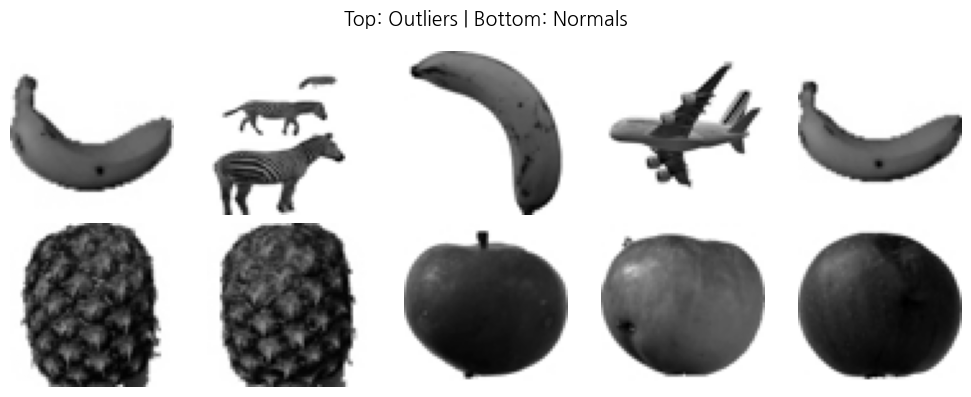

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

class Node:
    def __init__(self, idx, feature):
        self.idx = idx
        self.feature = feature
        self.neighbors = []
        self.updated_feature = feature.copy()

    def add_neighbor(self, neighbor):
        self.neighbors.append(neighbor)

    def aggregate(self):
        if not self.neighbors:
            return self.feature
        neighbor_features = [n.feature for n in self.neighbors]
        return np.mean(neighbor_features, axis=0)

    def update(self):
        self.updated_feature = (self.feature + self.aggregate()) / 2

def load_images_from_folder(folder, include_subfolders=False, img_size=(64, 64)):
    image_paths = []
    if include_subfolders:
        # 하위 폴더 포함 모든 이미지 경로 수집
        for root, _, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(root, f))
    else:
        # 최상위 폴더만 이미지 경로 수집
        for f in os.listdir(folder):
            full_path = os.path.join(folder, f)
            if os.path.isfile(full_path) and f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(full_path)

    images = []
    for path in tqdm(image_paths, desc="Loading images"):
        img = Image.open(path).convert("L").resize(img_size)
        images.append(np.array(img).flatten())
    return np.array(images), image_paths

def build_graph(features, similarity_threshold=0.8):
    features = normalize(features)
    sim_matrix = cosine_similarity(features)
    nodes = [Node(i, f) for i, f in enumerate(features)]
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if i != j and sim_matrix[i][j] > similarity_threshold:
                nodes[i].add_neighbor(nodes[j])
    return nodes

def run_gnn(nodes, epochs=1):
    for _ in range(epochs):
        for node in nodes:
            node.update()
        for node in nodes:
            node.feature = node.updated_feature.copy()
    return np.array([node.feature for node in nodes])

def detect_outliers(image_folder,
                    include_subfolders=False,
                    n_clusters=5,
                    outlier_ratio=0.1,
                    similarity_threshold=0.8,
                    gnn_epochs=1,
                    img_size=(64, 64)):
    features, image_paths = load_images_from_folder(image_folder, include_subfolders, img_size)
    if len(features) < n_clusters:
        raise ValueError(f"Number of images ({len(features)}) is less than the number of clusters ({n_clusters})")
    nodes = build_graph(features, similarity_threshold=similarity_threshold)
    embeddings = run_gnn(nodes, epochs=gnn_epochs)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    centers = kmeans.cluster_centers_

    dists = np.linalg.norm(embeddings - centers[labels], axis=1)
    cluster_errors = {i: [] for i in range(n_clusters)}
    for i, label in enumerate(labels):
        cluster_errors[label].append(dists[i])

    cluster_avg_error = {i: np.mean(cluster_errors[i]) for i in range(n_clusters)}
    sorted_clusters = sorted(cluster_avg_error.items(), key=lambda x: x[1], reverse=True)
    n_outlier_clusters = max(1, int(len(sorted_clusters) * outlier_ratio))
    outlier_cluster_ids = [cid for cid, _ in sorted_clusters[:n_outlier_clusters]]

    outlier_indices = [i for i, label in enumerate(labels) if label in outlier_cluster_ids]
    return [image_paths[i] for i in outlier_indices], image_paths, outlier_indices

def show_outliers_vs_normals(image_paths, outlier_indices, img_size=(64, 64), num_show=5):
    normal_indices = [i for i in range(len(image_paths)) if i not in outlier_indices]
    num_show = min(num_show, len(outlier_indices), len(normal_indices))

    if num_show == 0:
        print("시각화할 이상치 또는 정상 이미지가 충분하지 않습니다.")
        return

    fig, axes = plt.subplots(2, num_show, figsize=(num_show * 2, 4))
    fig.suptitle("Top: Outliers | Bottom: Normals", fontsize=14)
    for i in range(num_show):
        out_img = Image.open(image_paths[outlier_indices[i]]).convert("L").resize(img_size)
        norm_img = Image.open(image_paths[normal_indices[i]]).convert("L").resize(img_size)
        axes[0, i].imshow(out_img, cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(norm_img, cmap='gray')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # 설정 예시
    image_folder = "imgData/mini_final"
    include_subfolders = False  # 하위폴더 포함할지 여부 선택
    n_clusters = 5
    outlier_ratio = 0.2
    similarity_threshold = 0.8
    gnn_epochs = 2
    img_size = (64, 64)

    outlier_paths, all_paths, outlier_indices = detect_outliers(
        image_folder=image_folder,
        include_subfolders=include_subfolders,
        n_clusters=n_clusters,
        outlier_ratio=outlier_ratio,
        similarity_threshold=similarity_threshold,
        gnn_epochs=gnn_epochs,
        img_size=img_size
    )

    print("Detected outliers:")
    outlier = 0
    total = 0
    for path in outlier_paths:
        print(path)
        if len(path.split('_'))==2:
          outlier = outlier + 1
        total = total + 1

    print(f"True outliers: {outlier}")
    print(f"Total outliers: {total}")


    show_outliers_vs_normals(all_paths, outlier_indices, img_size=img_size)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

class Node:
    def __init__(self, idx, feature):
        self.idx = idx
        self.feature = feature
        self.neighbors = []
        self.updated_feature = feature.copy()

    def add_neighbor(self, neighbor):
        self.neighbors.append(neighbor)

    def aggregate(self):
        if not self.neighbors:
            return self.feature
        neighbor_features = [n.feature for n in self.neighbors]
        return np.mean(neighbor_features, axis=0)

    def update(self):
        self.updated_feature = (self.feature + self.aggregate()) / 2

def load_images_from_folder(folder, include_subfolders=False, img_size=(64, 64)):
    image_paths = []
    if include_subfolders:
        # 하위 폴더 포함 모든 이미지 경로 수집
        for root, _, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(root, f))
    else:
        # 최상위 폴더만 이미지 경로 수집
        for f in os.listdir(folder):
            full_path = os.path.join(folder, f)
            if os.path.isfile(full_path) and f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(full_path)

    images = []
    for path in tqdm(image_paths, desc="Loading images"):
        img = Image.open(path).convert("L").resize(img_size)
        images.append(np.array(img).flatten())
    return np.array(images), image_paths

def build_graph(features, similarity_threshold=0.8):
    features = normalize(features)
    sim_matrix = cosine_similarity(features)
    nodes = [Node(i, f) for i, f in enumerate(features)]
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if i != j and sim_matrix[i][j] > similarity_threshold:
                nodes[i].add_neighbor(nodes[j])
    return nodes

def run_gnn(nodes, epochs=1):
    for _ in range(epochs):
        for node in nodes:
            node.update()
        for node in nodes:
            node.feature = node.updated_feature.copy()
    return np.array([node.feature for node in nodes])

def detect_outliers(image_folder,
                    include_subfolders=False,
                    n_clusters=5,
                    outlier_ratio=0.1,
                    similarity_threshold=0.8,
                    gnn_epochs=1,
                    img_size=(64, 64)):
    features, image_paths = load_images_from_folder(image_folder, include_subfolders, img_size)
    if len(features) < n_clusters:
        raise ValueError(f"Number of images ({len(features)}) is less than the number of clusters ({n_clusters})")
    nodes = build_graph(features, similarity_threshold=similarity_threshold)
    embeddings = run_gnn(nodes, epochs=gnn_epochs)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    centers = kmeans.cluster_centers_

    dists = np.linalg.norm(embeddings - centers[labels], axis=1)
    cluster_errors = {i: [] for i in range(n_clusters)}
    for i, label in enumerate(labels):
        cluster_errors[label].append(dists[i])

    cluster_avg_error = {i: np.mean(cluster_errors[i]) for i in range(n_clusters)}
    sorted_clusters = sorted(cluster_avg_error.items(), key=lambda x: x[1], reverse=True)
    n_outlier_clusters = max(1, int(len(sorted_clusters) * outlier_ratio))
    outlier_cluster_ids = [cid for cid, _ in sorted_clusters[:n_outlier_clusters]]

    outlier_indices = [i for i, label in enumerate(labels) if label in outlier_cluster_ids]
    return [image_paths[i] for i in outlier_indices], image_paths, outlier_indices

def show_outliers_vs_normals(image_paths, outlier_indices, img_size=(64, 64), num_show=5):
    normal_indices = [i for i in range(len(image_paths)) if i not in outlier_indices]
    num_show = min(num_show, len(outlier_indices), len(normal_indices))

    if num_show == 0:
        print("시각화할 이상치 또는 정상 이미지가 충분하지 않습니다.")
        return

    fig, axes = plt.subplots(2, num_show, figsize=(num_show * 2, 4))
    fig.suptitle("Top: Outliers | Bottom: Normals", fontsize=14)
    for i in range(num_show):
        out_img = Image.open(image_paths[outlier_indices[i]]).convert("L").resize(img_size)
        norm_img = Image.open(image_paths[normal_indices[i]]).convert("L").resize(img_size)
        axes[0, i].imshow(out_img, cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(norm_img, cmap='gray')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()
from itertools import product

def tune_hyperparameters(image_folder,
                         include_subfolders,
                         n_clusters_list,
                         outlier_ratio_list,
                         similarity_threshold_list,
                         gnn_epochs_list,
                         img_size=(64, 64)):
    best_config = None
    best_score = None  # 예: 이상치 수 최대화 혹은 오차 최소화 등 기준 선택
    results = []

    for n_clusters, outlier_ratio, similarity_threshold, gnn_epochs in product(
        n_clusters_list, outlier_ratio_list, similarity_threshold_list, gnn_epochs_list):

        try:
            outlier_paths, all_paths, outlier_indices = detect_outliers(
                image_folder=image_folder,
                include_subfolders=include_subfolders,
                n_clusters=n_clusters,
                outlier_ratio=outlier_ratio,
                similarity_threshold=similarity_threshold,
                gnn_epochs=gnn_epochs,
                img_size=img_size
            )
            # 평가 기준 예시: 이상치 개수 (클수록 더 민감하게 이상치 탐지)
            score = len(outlier_paths)
            results.append({
                'n_clusters': n_clusters,
                'outlier_ratio': outlier_ratio,
                'similarity_threshold': similarity_threshold,
                'gnn_epochs': gnn_epochs,
                'outlier_count': score
            })

            # 여기서는 이상치 개수 최대화를 목표로 함
            if best_score is None or score > best_score:
                best_score = score
                best_config = (n_clusters, outlier_ratio, similarity_threshold, gnn_epochs)

        except Exception as e:
            print(f"Error with config (n_clusters={n_clusters}, outlier_ratio={outlier_ratio}, "
                  f"similarity_threshold={similarity_threshold}, gnn_epochs={gnn_epochs}): {e}")

    return best_config, best_score, results

# --- 사용 예시 ---

if __name__ == "__main__":
    image_folder = "image"
    include_subfolders = True

    n_clusters_list = [3, 5, 7]
    outlier_ratio_list = [0.1, 0.2]
    similarity_threshold_list = [0.75, 0.8]
    gnn_epochs_list = [1, 2]

    best_config, best_score, results = tune_hyperparameters(
        image_folder=image_folder,
        include_subfolders=include_subfolders,
        n_clusters_list=n_clusters_list,
        outlier_ratio_list=outlier_ratio_list,
        similarity_threshold_list=similarity_threshold_list,
        gnn_epochs_list=gnn_epochs_list,
        img_size=(64,64)
    )

    print("Best config:", best_config)
    print("Best outlier count:", best_score)
    print("All results:")
    for r in results:
        print(r)


Loading images: 100%|██████████| 7/7 [00:00<00:00, 35.50it/s]


Best config: (3, 0.1, 0.75, 1)
Best outlier count: 5
All results:
{'n_clusters': 3, 'outlier_ratio': 0.1, 'similarity_threshold': 0.75, 'gnn_epochs': 1, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.1, 'similarity_threshold': 0.75, 'gnn_epochs': 2, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.1, 'similarity_threshold': 0.8, 'gnn_epochs': 1, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.1, 'similarity_threshold': 0.8, 'gnn_epochs': 2, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.2, 'similarity_threshold': 0.75, 'gnn_epochs': 1, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.2, 'similarity_threshold': 0.75, 'gnn_epochs': 2, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.2, 'similarity_threshold': 0.8, 'gnn_epochs': 1, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.2, 'similarity_threshold': 0.8, 'gnn_epochs': 2, 'outlier_count': 5}
{'n_clusters': 5, 'outlier_ratio': 0.1, 'similarity_threshold': 0.75, 'gnn_epochs'

Best config: (3, 0.1, 0.75, 1)
Best outlier count: 230
Detected outliers:
imgData/mini_final/68_100.jpg
imgData/mini_final/000000000154.jpg
imgData/mini_final/r1_274_100.jpg
imgData/mini_final/000000000081.jpg
imgData/mini_final/r0_270_100.jpg
imgData/mini_final/r0_277_100.jpg
imgData/mini_final/r0_241_100.jpg
imgData/mini_final/79_100.jpg
imgData/mini_final/98_100.jpg
imgData/mini_final/r0_245_100.jpg
imgData/mini_final/70_100.jpg
imgData/mini_final/r1_259_100.jpg
imgData/mini_final/r0_273_100.jpg
imgData/mini_final/r1_266_100.jpg
imgData/mini_final/r0_179_100.jpg
imgData/mini_final/000000000092.jpg
imgData/mini_final/r0_249_100.jpg
imgData/mini_final/000000001381.jpg
imgData/mini_final/86_100.jpg
imgData/mini_final/000000001307.jpg
imgData/mini_final/r1_268_100.jpg
imgData/mini_final/000000001436.jpg
imgData/mini_final/000000001448.jpg
imgData/mini_final/r0_279_100.jpg
imgData/mini_final/77_100.jpg
imgData/mini_final/95_100.jpg
imgData/mini_final/61_100.jpg
imgData/mini_final/r0_237_

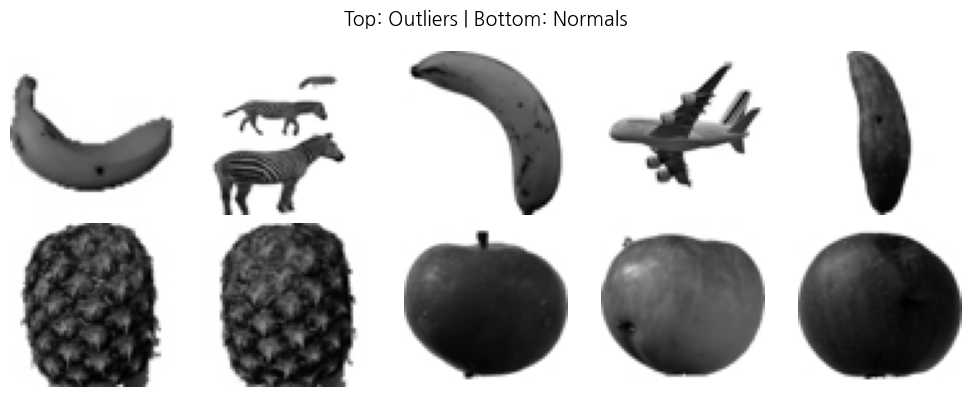

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from itertools import product

# --- Node 클래스 정의 ---
class Node:
    def __init__(self, feature, idx):
        self.feature = feature  # 이미지 벡터
        self.idx = idx          # 원본 이미지 인덱스
        self.neighbors = []
        self.state = feature.copy()  # GNN 상태 초기값

    def add_neighbor(self, neighbor):
        self.neighbors.append(neighbor)

    def update_state(self):
        if not self.neighbors:
            return
        agg = np.mean([n.state for n in self.neighbors], axis=0)
        self.state = 0.5 * self.state + 0.5 * agg  # simple mean aggregation

# --- 이미지 불러오기 ---
def load_images_from_folder(folder_path, include_subfolders=True, img_size=(64,64)):
    image_paths = []
    if include_subfolders:
        for root, _, files in os.walk(folder_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    image_paths.append(os.path.join(root, file))
    else:
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                image_paths.append(os.path.join(folder_path, file))

    features = []
    for path in image_paths:
        img = Image.open(path).convert("L").resize(img_size)
        features.append(np.array(img).flatten() / 255.0)  # 정규화 후 1D 벡터로 변환
    return features, image_paths

# --- 그래프 생성 ---
def build_graph(nodes, similarity_threshold=0.8):
    for i, node_i in enumerate(nodes):
        for j in range(i+1, len(nodes)):
            node_j = nodes[j]
            sim = cosine_similarity(node_i.feature, node_j.feature)
            if sim >= similarity_threshold:
                node_i.add_neighbor(node_j)
                node_j.add_neighbor(node_i)

def cosine_similarity(a, b):
    if np.linalg.norm(a)==0 or np.linalg.norm(b)==0:
        return 0
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# --- GNN 업데이트 ---
def run_gnn(nodes, epochs=2):
    for _ in range(epochs):
        new_states = []
        for node in nodes:
            if not node.neighbors:
                new_states.append(node.state)
                continue
            agg = np.mean([n.state for n in node.neighbors], axis=0)
            new_state = 0.5 * node.state + 0.5 * agg
            new_states.append(new_state)
        for node, ns in zip(nodes, new_states):
            node.state = ns

# --- 군집화 후 이상치 탐지 ---
def cluster_and_detect_outliers(nodes, n_clusters=3, outlier_ratio=0.1):
    X = np.array([node.state for node in nodes])
    if len(X) < n_clusters:
        n_clusters = max(1, len(X))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    # 각 노드가 클러스터 중심과 얼마나 차이나는지 계산 (오차)
    errors = np.linalg.norm(X - centers[labels], axis=1)

    # 클러스터별 평균 오차 계산
    cluster_errors = []
    for c in range(n_clusters):
        cluster_errors.append(np.mean(errors[labels==c]))

    # 오차 기준 상위 outlier_ratio만큼 클러스터 선택
    num_outlier_clusters = max(1, int(n_clusters * outlier_ratio))
    outlier_cluster_indices = np.argsort(cluster_errors)[-num_outlier_clusters:]

    # 이상치 노드 인덱스 추출
    outlier_indices = [i for i, label in enumerate(labels) if label in outlier_cluster_indices]

    return outlier_indices

# --- 이상치 및 정상 이미지 시각화 ---
def show_outliers_vs_normals(image_paths, outlier_indices, img_size=(64, 64), num_show=5):
    normal_indices = [i for i in range(len(image_paths)) if i not in outlier_indices]
    num_show = min(num_show, len(outlier_indices), len(normal_indices))
    if num_show == 0:
        print("시각화할 이상치 또는 정상 이미지가 충분하지 않습니다.")
        return

    fig, axes = plt.subplots(2, num_show, figsize=(num_show * 2, 4))
    fig.suptitle("Top: Outliers | Bottom: Normals", fontsize=14)

    if num_show == 1:
        # axes가 1차원 배열 (길이 2)
        axes_outliers = axes[0]
        axes_normals = axes[1]
        out_img = Image.open(image_paths[outlier_indices[0]]).convert("L").resize(img_size)
        norm_img = Image.open(image_paths[normal_indices[0]]).convert("L").resize(img_size)
        axes_outliers.imshow(out_img, cmap='gray')
        axes_outliers.axis('off')
        axes_normals.imshow(norm_img, cmap='gray')
        axes_normals.axis('off')
    else:
        for i in range(num_show):
            out_img = Image.open(image_paths[outlier_indices[i]]).convert("L").resize(img_size)
            norm_img = Image.open(image_paths[normal_indices[i]]).convert("L").resize(img_size)
            axes[0, i].imshow(out_img, cmap='gray')
            axes[0, i].axis('off')
            axes[1, i].imshow(norm_img, cmap='gray')
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# --- 전체 파이프라인 ---
def detect_outliers(image_folder,
                    include_subfolders=True,
                    n_clusters=3,
                    outlier_ratio=0.1,
                    similarity_threshold=0.8,
                    gnn_epochs=2,
                    img_size=(64, 64)):
    features, image_paths = load_images_from_folder(image_folder, include_subfolders, img_size)
    if len(features) == 0:
        print("이미지를 찾을 수 없습니다.")
        return [], [], []

    nodes = [Node(f, idx) for idx, f in enumerate(features)]
    build_graph(nodes, similarity_threshold)
    run_gnn(nodes, gnn_epochs)
    outlier_indices = cluster_and_detect_outliers(nodes, n_clusters, outlier_ratio)
    outlier_paths = [image_paths[i] for i in outlier_indices]
    return outlier_paths, image_paths, outlier_indices

# --- 하이퍼파라미터 튜닝 자동화 ---
def tune_hyperparameters(image_folder,
                         include_subfolders,
                         n_clusters_list,
                         outlier_ratio_list,
                         similarity_threshold_list,
                         gnn_epochs_list,
                         img_size=(64, 64)):
    best_config = None
    best_score = None
    results = []

    for n_clusters, outlier_ratio, similarity_threshold, gnn_epochs in product(
        n_clusters_list, outlier_ratio_list, similarity_threshold_list, gnn_epochs_list):

        try:
            outlier_paths, all_paths, outlier_indices = detect_outliers(
                image_folder=image_folder,
                include_subfolders=include_subfolders,
                n_clusters=n_clusters,
                outlier_ratio=outlier_ratio,
                similarity_threshold=similarity_threshold,
                gnn_epochs=gnn_epochs,
                img_size=img_size
            )
            score = len(outlier_paths)  # 이상치 개수 기준 예시
            results.append({
                'n_clusters': n_clusters,
                'outlier_ratio': outlier_ratio,
                'similarity_threshold': similarity_threshold,
                'gnn_epochs': gnn_epochs,
                'outlier_count': score
            })

            if best_score is None or score > best_score:
                best_score = score
                best_config = (n_clusters, outlier_ratio, similarity_threshold, gnn_epochs)

        except Exception as e:
            print(f"Error with config (n_clusters={n_clusters}, outlier_ratio={outlier_ratio}, "
                  f"similarity_threshold={similarity_threshold}, gnn_epochs={gnn_epochs}): {e}")

    return best_config, best_score, results

# --- 실행 예시 ---
if __name__ == "__main__":
    image_folder = "imgData"  # 이미지 폴더 경로 지정
    include_subfolders = True  # 하위 폴더 포함 여부

    # 하이퍼파라미터 후보값 설정
    n_clusters_list = [3, 5, 7]
    outlier_ratio_list = [0.1, 0.2]
    similarity_threshold_list = [0.75, 0.8]
    gnn_epochs_list = [1, 2]

    # 하이퍼파라미터 튜닝 실행
    best_config, best_score, results = tune_hyperparameters(
        image_folder=image_folder,
        include_subfolders=include_subfolders,
        n_clusters_list=n_clusters_list,
        outlier_ratio_list=outlier_ratio_list,
        similarity_threshold_list=similarity_threshold_list,
        gnn_epochs_list=gnn_epochs_list,
        img_size=(64, 64)
    )

    print("Best config:", best_config)
    print("Best outlier count:", best_score)

    # 튜닝된 최적값으로 이상치 탐지 및 시각화
    outlier_paths, all_paths, outlier_indices = detect_outliers(
        image_folder=image_folder,
        include_subfolders=include_subfolders,
        n_clusters=best_config[0],
        outlier_ratio=best_config[1],
        similarity_threshold=best_config[2],
        gnn_epochs=best_config[3],
        img_size=(64, 64)
    )

    print("Detected outliers:")
    for path in outlier_paths:
        print(path)

    show_outliers_vs_normals(all_paths, outlier_indices, img_size=(64, 64), num_show=5)


Loading images: 100%|██████████| 500/500 [00:00<00:00, 1680.75it/s]


Best Hyperparameter Configuration:
{'num_clusters': 3, 'top_outlier_percent': 0.1, 'gnn_steps': 2, 'include_subfolders': True}

Detected Outlier Files:
imgData/mini_final/68_100.jpg
imgData/mini_final/000000000154.jpg
imgData/mini_final/r1_274_100.jpg
imgData/mini_final/000000000081.jpg
imgData/mini_final/r0_270_100.jpg
imgData/mini_final/r0_277_100.jpg
imgData/mini_final/r0_241_100.jpg
imgData/mini_final/79_100.jpg
imgData/mini_final/98_100.jpg
imgData/mini_final/r0_245_100.jpg
imgData/mini_final/70_100.jpg
imgData/mini_final/r1_259_100.jpg
imgData/mini_final/r0_273_100.jpg
imgData/mini_final/r1_266_100.jpg
imgData/mini_final/r0_179_100.jpg
imgData/mini_final/000000000092.jpg
imgData/mini_final/r0_249_100.jpg
imgData/mini_final/000000001381.jpg
imgData/mini_final/86_100.jpg
imgData/mini_final/000000001307.jpg
imgData/mini_final/r1_268_100.jpg
imgData/mini_final/000000001436.jpg
imgData/mini_final/000000001448.jpg
imgData/mini_final/r0_279_100.jpg
imgData/mini_final/77_100.jpg
imgData/

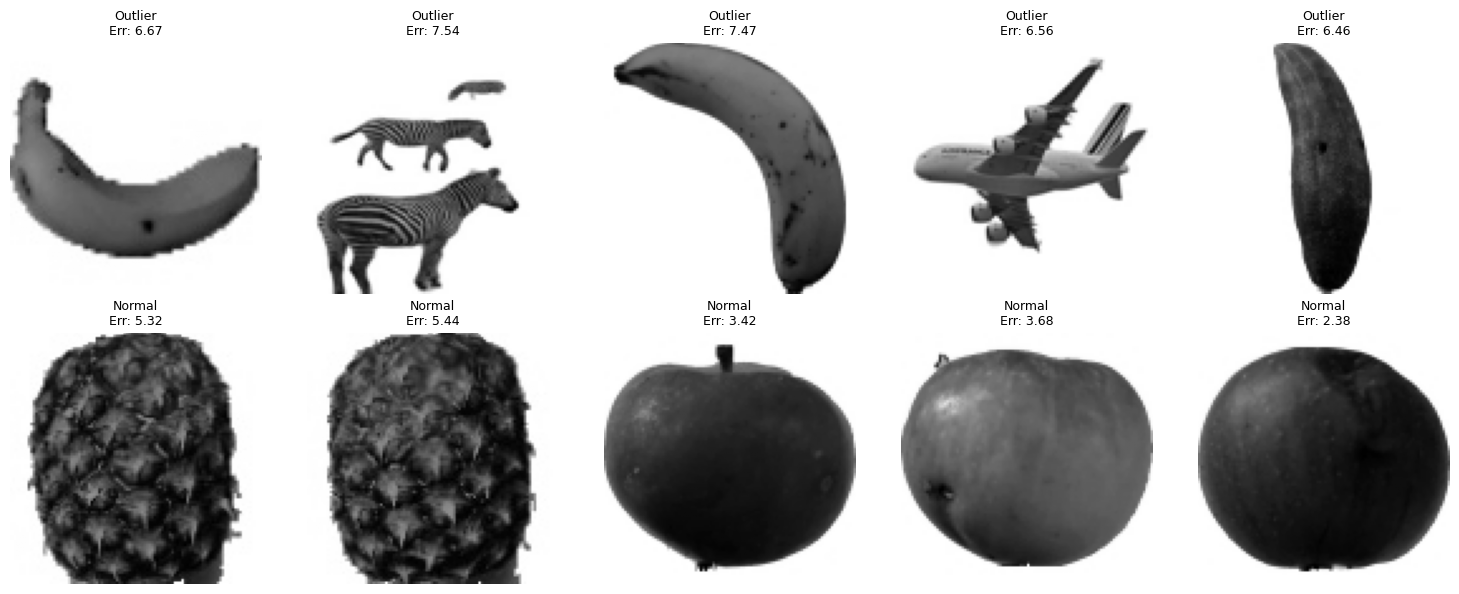

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from itertools import product
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

# ----------------------------
# Hyperparameters
# ----------------------------
def get_hyperparameter_grid():
    return {
        "num_clusters": [3, 5, 8],
        "top_outlier_percent": [0.1, 0.2],
        "gnn_steps": [1, 2],
        "include_subfolders": [True, False]
    }

# ----------------------------
# Image loading and flattening
# ----------------------------
def load_images_from_folder(folder, size=(64, 64), include_subfolders=True):
    image_paths = []
    for root, dirs, files in os.walk(folder):
        if not include_subfolders and root != folder:
            continue
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg', 'bmp')):
                image_paths.append(os.path.join(root, file))

    vectors = []
    for path in tqdm(image_paths, desc="Loading images"):
        try:
            img = Image.open(path).convert("L").resize(size)
            vectors.append(np.asarray(img).flatten() / 255.0)
        except:
            continue

    return np.array(vectors), image_paths

# ----------------------------
# GNN-inspired node class
# ----------------------------
class Node:
    def __init__(self, features):
        self.features = features
        self.state = features.copy()

    def update(self, neighbors):
        if not neighbors:
            return
        neighbor_states = np.array([n.state for n in neighbors])
        self.state = 0.5 * self.state + 0.5 * neighbor_states.mean(axis=0)

# ----------------------------
# Build similarity-based graph
# ----------------------------
def build_graph(vectors, threshold=0.5):
    nodes = [Node(vec) for vec in vectors]
    edges = [[] for _ in range(len(nodes))]
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            sim = np.dot(nodes[i].features, nodes[j].features)
            if sim > threshold:
                edges[i].append(nodes[j])
                edges[j].append(nodes[i])
    return nodes, edges

# ----------------------------
# GNN state propagation
# ----------------------------
def gnn_propagate(nodes, edges, steps):
    for _ in range(steps):
        for i, node in enumerate(nodes):
            node.update(edges[i])

# ----------------------------
# Clustering & Outlier Detection
# ----------------------------
def find_outliers_from_clusters(vectors, image_paths, num_clusters=5, top_percent=0.1):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(vectors)
    distances = kmeans.transform(vectors)
    min_distances = distances.min(axis=1)

    cluster_errors = [[] for _ in range(num_clusters)]
    for i, (label, dist) in enumerate(zip(labels, min_distances)):
        cluster_errors[label].append((i, dist))

    cluster_avg_error = [np.mean([e[1] for e in group]) if group else 0 for group in cluster_errors]
    num_top_clusters = max(1, int(num_clusters * top_percent))
    worst_clusters = np.argsort(cluster_avg_error)[-num_top_clusters:]

    outlier_indices = [idx for cluster in worst_clusters for idx, _ in cluster_errors[cluster]]
    return outlier_indices, min_distances

# ----------------------------
# Visualization with labels and distances
# ----------------------------
def show_outliers_vs_normals_with_info(image_paths, outlier_indices, distances, img_size=(64, 64), num_show=5, true_labels=None):
    num_outliers = len(outlier_indices)
    num_show = min(num_show, num_outliers)

    if num_show == 0:
        print("No outliers to display.")
        return

    normal_indices = [i for i in range(len(image_paths)) if i not in outlier_indices]
    if len(normal_indices) < num_show:
        print("Not enough normal samples for comparison.")
        return

    fig = plt.figure(figsize=(num_show * 3, 6))
    spec = gridspec.GridSpec(2, num_show)

    for i in range(num_show):
        out_idx = outlier_indices[i]
        norm_idx = normal_indices[i]

        out_img = Image.open(image_paths[out_idx]).convert("L").resize(img_size)
        norm_img = Image.open(image_paths[norm_idx]).convert("L").resize(img_size)

        ax1 = fig.add_subplot(spec[0, i])
        ax1.imshow(out_img, cmap='gray')
        ax1.axis('off')
        title1 = f"Outlier\nErr: {distances[out_idx]:.2f}"
        if true_labels:
            title1 += f"\nLabel: {true_labels[out_idx]}"
        ax1.set_title(title1, fontsize=9)

        ax2 = fig.add_subplot(spec[1, i])
        ax2.imshow(norm_img, cmap='gray')
        ax2.axis('off')
        title2 = f"Normal\nErr: {distances[norm_idx]:.2f}"
        if true_labels:
            title2 += f"\nLabel: {true_labels[norm_idx]}"
        ax2.set_title(title2, fontsize=9)

    plt.tight_layout()
    plt.show()

# ----------------------------
# Auto hyperparameter tuning
# ----------------------------
def auto_tune_hyperparams(folder, img_size=(64, 64)):
    grid = get_hyperparameter_grid()
    best_config = None
    best_score = -1
    best_outliers = []
    best_vectors = []
    best_paths = []
    best_distances = []

    for config in product(*grid.values()):
        config_dict = dict(zip(grid.keys(), config))
        vectors, paths = load_images_from_folder(folder, size=img_size, include_subfolders=config_dict["include_subfolders"])
        if len(vectors) < config_dict["num_clusters"]:
            continue

        nodes, edges = build_graph(vectors)
        gnn_propagate(nodes, edges, config_dict["gnn_steps"])
        updated_vectors = np.array([n.state for n in nodes])

        outlier_indices, distances = find_outliers_from_clusters(
            updated_vectors, paths,
            num_clusters=config_dict["num_clusters"],
            top_percent=config_dict["top_outlier_percent"]
        )

        score = len(outlier_indices)
        if score > best_score:
            best_score = score
            best_config = config_dict
            best_outliers = outlier_indices
            best_vectors = updated_vectors
            best_paths = paths
            best_distances = distances

    return best_config, best_outliers, best_vectors, best_paths, best_distances

# ----------------------------
# Entry point
# ----------------------------
if __name__ == "__main__":
    folder = "imgData/mini_final"  # change this to your actual image folder path
    img_size = (100, 100)

    best_config, outlier_indices, vectors, all_paths, distances = auto_tune_hyperparams(folder, img_size)

    print("Best Hyperparameter Configuration:")
    print(best_config)

    print("\nDetected Outlier Files:")
    for idx in outlier_indices:
        print(all_paths[idx])

    show_outliers_vs_normals_with_info(
        image_paths=all_paths,
        outlier_indices=outlier_indices,
        distances=distances,
        img_size=img_size,
        num_show=5,
        true_labels=None  # If available, you can add true labels here
    )


In [ ]:
# 1. 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 2. zip 파일 경로 및 압축 풀 위치 지정
zip_path = '/content/drive/MyDrive/mini_final.zip'  # 이 경로는 사용자의 파일 위치에 맞게 수정하세요
extract_path = '/content/imgData'  # 압축을 풀 위치

# 3. 압축 풀기
import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 4. 압축 푼 파일 목록 출력
import os
print(f"\n🔍 압축이 풀린 파일 목록 ({extract_path}):\n")
for root, dirs, files in os.walk(extract_path):
    for name in files:
        print(os.path.join(root, name))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔍 압축이 풀린 파일 목록 (/content/imgData):

/content/imgData/mini_final/180_100.jpg
/content/imgData/mini_final/217_100.jpg
/content/imgData/mini_final/68_100.jpg
/content/imgData/mini_final/000000000154.jpg
/content/imgData/mini_final/r0_24_100.jpg
/content/imgData/mini_final/r0_48_100.jpg
/content/imgData/mini_final/r1_274_100.jpg
/content/imgData/mini_final/r0_119_100.jpg
/content/imgData/mini_final/r0_59_100.jpg
/content/imgData/mini_final/38_100.jpg
/content/imgData/mini_final/r0_108_100.jpg
/content/imgData/mini_final/r_119_100.jpg
/content/imgData/mini_final/000000000081.jpg
/content/imgData/mini_final/r0_270_100.jpg
/content/imgData/mini_final/r0_40_100.jpg
/content/imgData/mini_final/r0_50_100.jpg
/content/imgData/mini_final/r0_121_100.jpg
/content/imgData/mini_final/r0_277_100.jpg
/content/imgData/mini_final/r_125_100.jpg
/content/imgData/mini_final/43_100

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from tqdm import tqdm

# ----- 하이퍼파라미터 -----
embedding_dim = 128
hidden_dim = 64
num_neighbors = 5
num_epochs = 10
learning_rate = 0.01
outlier_threshold = 2.0  # z-score 기준
use_subdirs = True
image_dir = "./images"

# ----- 이미지 로딩 및 임베딩 -----
def get_image_paths(image_dir, use_subdirs):
    paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                paths.append(os.path.join(root, file))
        if not use_subdirs:
            break
    return paths

class ImageEncoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        x = self.feature_extractor(x).squeeze()
        return self.proj(x)

def extract_embeddings(image_paths, encoder, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    embeddings = []
    encoder.eval()
    with torch.no_grad():
        for path in tqdm(image_paths):
            img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
            emb = encoder(img).cpu().numpy().flatten()
            embeddings.append(emb)
    return np.array(embeddings)

# ----- Node 정의 및 Graph 구성 -----
class Node:
    def __init__(self, idx, embedding):
        self.idx = idx
        self.embedding = embedding
        self.neighbors = []

def build_graph(embeddings, k=5):
    nodes = [Node(i, emb) for i, emb in enumerate(embeddings)]
    sims = cosine_similarity(embeddings)
    for i, node in enumerate(nodes):
        topk = np.argsort(-sims[i])[1:k+1]
        node.neighbors = [nodes[j] for j in topk]
    return nodes

# ----- GraphSAGE 수동 구현 -----
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, nodes, embeddings):
        new_embeddings = []
        for node in nodes:
            if node.neighbors:
                neighbor_embs = torch.stack([embeddings[n.idx] for n in node.neighbors])
                agg = neighbor_embs.mean(dim=0)
            else:
                agg = torch.zeros_like(embeddings[node.idx])
            combined = torch.cat([embeddings[node.idx], agg])
            new_emb = self.linear(combined)
            new_embeddings.append(new_emb)
        return torch.stack(new_embeddings)

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hidden_dim)
        self.sage2 = GraphSAGELayer(hidden_dim, hidden_dim)

    def forward(self, nodes):
        emb = torch.stack([torch.tensor(n.embedding, dtype=torch.float32) for n in nodes])
        emb1 = F.relu(self.sage1(nodes, emb))
        emb2 = self.sage2(nodes, emb1)
        return emb2

# ----- 이상치 탐지 -----
def detect_outliers(gnn_embeddings, threshold=2.0):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(gnn_embeddings)
    dists = np.linalg.norm(scaled - scaled.mean(axis=0), axis=1)
    z_scores = (dists - dists.mean()) / dists.std()
    return np.where(z_scores > threshold)[0]

# ----- 시각화 -----
def visualize_with_clusters(embeddings, outlier_indices, image_paths, n_clusters=5):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=60, picker=True)

    for i in outlier_indices:
        ax.scatter(reduced[i][0], reduced[i][1], edgecolors='black', facecolors='none', s=120, linewidths=2)

    ax.set_title("t-SNE with KMeans Clusters and Outliers")
    ax.legend(*scatter.legend_elements(), title="Clusters")

    def onpick(event):
        ind = event.ind[0]
        img_path = image_paths[ind]
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((150, 150), Image.LANCZOS)
        imagebox = OffsetImage(np.array(img), zoom=1)
        ab = AnnotationBbox(imagebox, reduced[ind], frameon=True)
        ax.add_artist(ab)
        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', onpick)
    plt.show()

# ----- 메인 실행 -----
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_paths = get_image_paths(image_dir, use_subdirs)
    encoder = ImageEncoder(embedding_dim).to(device)
    embeddings = extract_embeddings(image_paths, encoder, device)
    nodes = build_graph(embeddings, num_neighbors)

    model = GraphSAGE(embedding_dim, hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        gnn_out = model(nodes)
        loss = gnn_out.norm(dim=1).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    model.eval()
    final_embs = model(nodes).detach().cpu().numpy()
    outliers = detect_outliers(final_embs, outlier_threshold)

    print("\nDetected Outliers:")
    for idx in outliers:
        print(image_paths[idx])

    visualize_with_clusters(final_embs, outliers, image_paths, n_clusters=5)

if __name__ == "__main__":
    main()


In [ ]:
pip install torch torchvision matplotlib scikit-learn pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 952.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]
Extracting embeddings: 100%|██████████| 500/500 [00:51<00:00,  9.63it/s]


Epoch 1, Loss: 1.2453
Epoch 2, Loss: 2.6311
Epoch 3, Loss: 0.8011
Epoch 4, Loss: 0.3835
Epoch 5, Loss: 0.3573
Epoch 6, Loss: 0.3171
Epoch 7, Loss: 0.2725
Epoch 8, Loss: 0.2262
Epoch 9, Loss: 0.1806
Epoch 10, Loss: 0.1384

Detected Outliers:


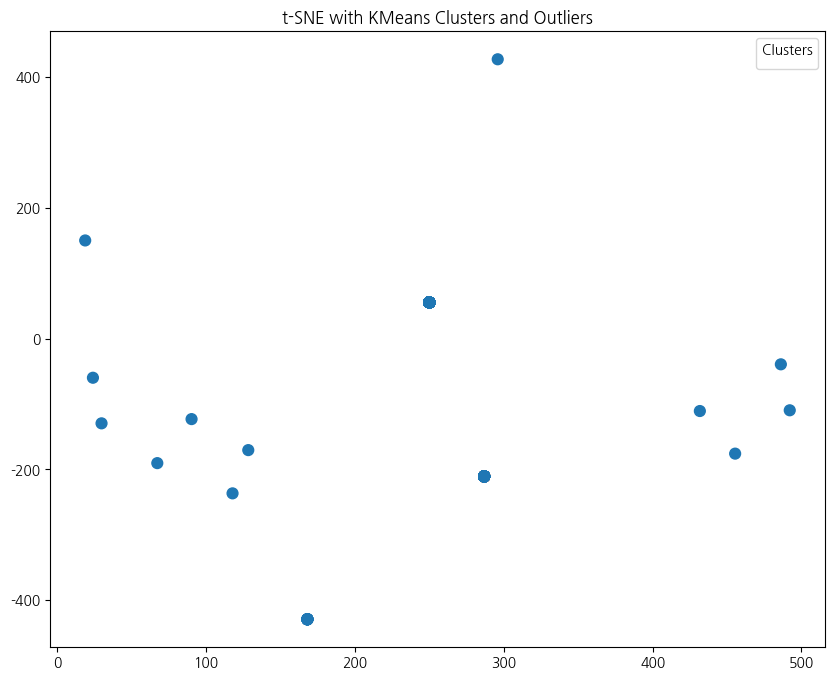

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from tqdm import tqdm

# 이미지 경로 수집
def get_image_paths(image_dir, use_subdirs):
    paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                paths.append(os.path.join(root, file))
        if not use_subdirs:
            break
    return paths

# 이미지 임베딩 추출기 정의
class ImageEncoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        x = self.feature_extractor(x).squeeze()
        return self.proj(x)

# 이미지에서 임베딩 추출
def extract_embeddings(image_paths, encoder, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    embeddings = []
    encoder.eval()
    with torch.no_grad():
        for path in tqdm(image_paths, desc="Extracting embeddings"):
            img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
            emb = encoder(img).cpu().numpy().flatten()
            embeddings.append(emb)
    return np.array(embeddings)

# Node 클래스
class Node:
    def __init__(self, idx, embedding):
        self.idx = idx
        self.embedding = embedding
        self.neighbors = []

# 그래프 구성
def build_graph(embeddings, k=5):
    nodes = [Node(i, emb) for i, emb in enumerate(embeddings)]
    sims = cosine_similarity(embeddings)
    for i, node in enumerate(nodes):
        topk = np.argsort(-sims[i])[1:k+1]
        node.neighbors = [nodes[j] for j in topk]
    return nodes

# GraphSAGE 레이어
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, nodes, embeddings):
        new_embeddings = []
        for node in nodes:
            if node.neighbors:
                neighbor_embs = torch.stack([embeddings[n.idx] for n in node.neighbors])
                agg = neighbor_embs.mean(dim=0)
            else:
                agg = torch.zeros_like(embeddings[node.idx])
            combined = torch.cat([embeddings[node.idx], agg])
            new_emb = self.linear(combined)
            new_embeddings.append(new_emb)
        return torch.stack(new_embeddings)

# GraphSAGE 모델
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hidden_dim)
        self.sage2 = GraphSAGELayer(hidden_dim, hidden_dim)

    def forward(self, nodes):
        emb = torch.stack([torch.tensor(n.embedding, dtype=torch.float32) for n in nodes])
        emb1 = F.relu(self.sage1(nodes, emb))
        emb2 = self.sage2(nodes, emb1)
        return emb2

# 이상치 탐지 (z-score)
def detect_outliers(gnn_embeddings, threshold=2.0):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(gnn_embeddings)
    dists = np.linalg.norm(scaled - scaled.mean(axis=0), axis=1)
    z_scores = (dists - dists.mean()) / dists.std()
    return np.where(z_scores > threshold)[0]

# 시각화
def visualize_with_clusters(embeddings, outlier_indices, image_paths, n_clusters=5):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=60, picker=True)

    for i in outlier_indices:
        ax.scatter(reduced[i][0], reduced[i][1], edgecolors='black', facecolors='none', s=120, linewidths=2)

    ax.set_title("t-SNE with KMeans Clusters and Outliers")
    ax.legend(*scatter.legend_elements(), title="Clusters")

    def onpick(event):
        ind = event.ind[0]
        img_path = image_paths[ind]
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((150, 150), Image.LANCZOS)
        imagebox = OffsetImage(np.array(img), zoom=1)
        ab = AnnotationBbox(imagebox, reduced[ind], frameon=True)
        ax.add_artist(ab)
        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', onpick)
    plt.show()

# 메인 함수
def main(config):
    image_dir = config["image_dir"]
    use_subdirs = config["use_subdirs"]
    embedding_dim = config["embedding_dim"]
    hidden_dim = config["hidden_dim"]
    num_neighbors = config["num_neighbors"]
    num_epochs = config["num_epochs"]
    learning_rate = config["learning_rate"]
    outlier_threshold = config["outlier_threshold"]
    n_clusters = config["n_clusters"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_paths = get_image_paths(image_dir, use_subdirs)
    encoder = ImageEncoder(embedding_dim).to(device)
    embeddings = extract_embeddings(image_paths, encoder, device)
    nodes = build_graph(embeddings, num_neighbors)

    model = GraphSAGE(embedding_dim, hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        gnn_out = model(nodes)
        loss = gnn_out.norm(dim=1).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    model.eval()
    final_embs = model(nodes).detach().cpu().numpy()
    outliers = detect_outliers(final_embs, outlier_threshold)

    print("\nDetected Outliers:")
    for idx in outliers:
        print(image_paths[idx])

    visualize_with_clusters(final_embs, outliers, image_paths, n_clusters=n_clusters)

# 실행부 - 하이퍼파라미터 설정
if __name__ == "__main__":
    config = {
        "image_dir": "imgData/mini_final",       # 이미지 폴더 경로
        "use_subdirs": False,           # 하위 폴더 포함 여부
        "embedding_dim": 128,          # 이미지 임베딩 차원
        "hidden_dim": 64,              # GNN 은닉 차원
        "num_neighbors": 5,            # KNN 그래프 이웃 수
        "num_epochs": 10,              # 학습 반복 횟수
        "learning_rate": 0.01,         # 학습률
        "outlier_threshold": 2.0,      # 이상치 탐지 임계값 (Z-score)
        "n_clusters": 5                # 시각화 클러스터 수
    }
    main(config)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Extracting embeddings: 100%|██████████| 500/500 [00:56<00:00,  8.92it/s]


Epoch 1, Loss: 1.3156
Epoch 2, Loss: 3.6970
Epoch 3, Loss: 0.8666
Epoch 4, Loss: 0.3843
Epoch 5, Loss: 0.3586
Epoch 6, Loss: 0.3218
Epoch 7, Loss: 0.2802
Epoch 8, Loss: 0.2364
Epoch 9, Loss: 0.1924
Epoch 10, Loss: 0.1498
Epoch 11, Loss: 0.1111
Epoch 12, Loss: 0.0821
Epoch 13, Loss: 0.0706
Epoch 14, Loss: 0.0753
Epoch 15, Loss: 0.0846
Epoch 16, Loss: 0.0912
Epoch 17, Loss: 0.0934
Epoch 18, Loss: 0.0915
Epoch 19, Loss: 0.0869
Epoch 20, Loss: 0.0811


<ipython-input-14-1ad7533494c9>:107: RuntimeWarning: invalid value encountered in divide
  z_scores = (dists - dists.mean()) / dists.std()



Detected Outliers:


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/matplotlib/collections.py:1121: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


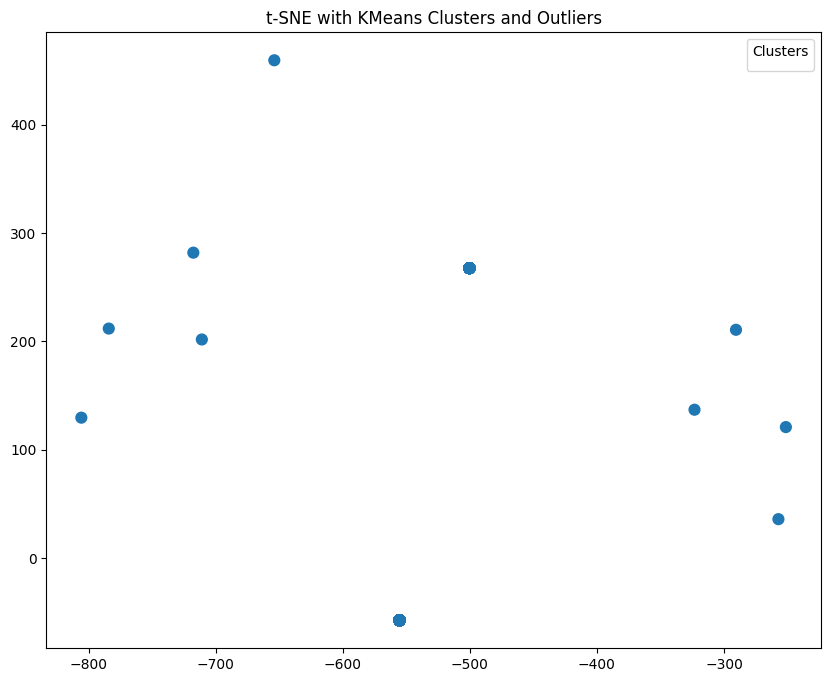

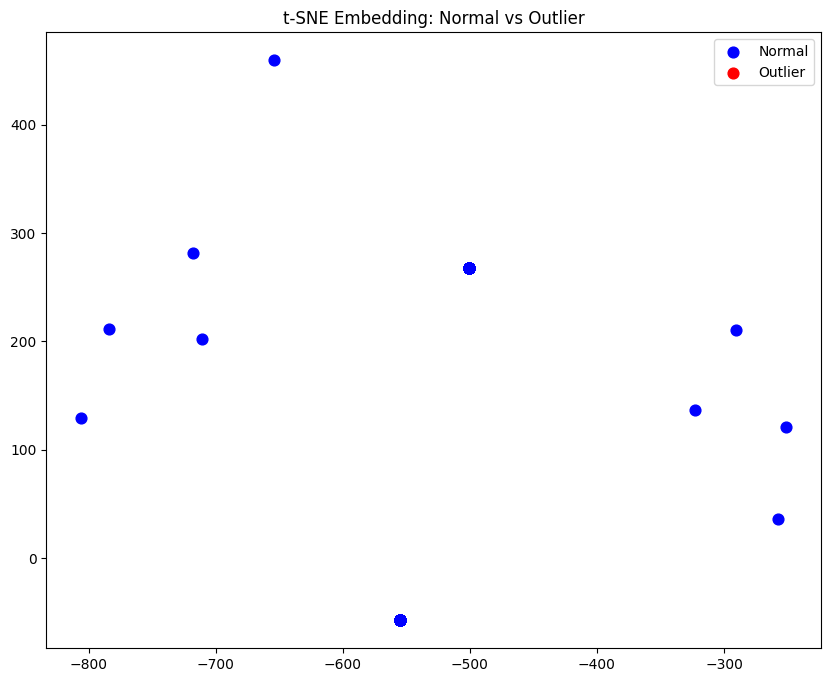

총 이미지 개수: 500
임베딩 shape: (500, 64)
이상치 인덱스: []


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from tqdm import tqdm

# 이미지 경로 수집
def get_image_paths(image_dir, use_subdirs):
    paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                paths.append(os.path.join(root, file))
        if not use_subdirs:
            break
    return paths

# 이미지 임베딩 추출기 정의
class ImageEncoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        x = self.feature_extractor(x).squeeze()
        return self.proj(x)

# 이미지에서 임베딩 추출
def extract_embeddings(image_paths, encoder, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    embeddings = []
    encoder.eval()
    with torch.no_grad():
        for path in tqdm(image_paths, desc="Extracting embeddings"):
            img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
            emb = encoder(img).cpu().numpy().flatten()
            embeddings.append(emb)
    return np.array(embeddings)

# Node 클래스
class Node:
    def __init__(self, idx, embedding):
        self.idx = idx
        self.embedding = embedding
        self.neighbors = []

# 그래프 구성
def build_graph(embeddings, k=5):
    nodes = [Node(i, emb) for i, emb in enumerate(embeddings)]
    sims = cosine_similarity(embeddings)
    for i, node in enumerate(nodes):
        topk = np.argsort(-sims[i])[1:k+1]
        node.neighbors = [nodes[j] for j in topk]
    return nodes

# GraphSAGE 레이어
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, nodes, embeddings):
        new_embeddings = []
        for node in nodes:
            if node.neighbors:
                neighbor_embs = torch.stack([embeddings[n.idx] for n in node.neighbors])
                agg = neighbor_embs.mean(dim=0)
            else:
                agg = torch.zeros_like(embeddings[node.idx])
            combined = torch.cat([embeddings[node.idx], agg])
            new_emb = self.linear(combined)
            new_embeddings.append(new_emb)
        return torch.stack(new_embeddings)

# GraphSAGE 모델
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hidden_dim)
        self.sage2 = GraphSAGELayer(hidden_dim, hidden_dim)

    def forward(self, nodes):
        emb = torch.stack([torch.tensor(n.embedding, dtype=torch.float32) for n in nodes])
        emb1 = F.relu(self.sage1(nodes, emb))
        emb2 = self.sage2(nodes, emb1)
        return emb2

# 이상치 탐지 (z-score)
def detect_outliers(gnn_embeddings, threshold=2.0):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(gnn_embeddings)
    dists = np.linalg.norm(scaled - scaled.mean(axis=0), axis=1)
    z_scores = (dists - dists.mean()) / dists.std()
    return np.where(z_scores > threshold)[0]

# 군집 기반 시각화
def visualize_with_clusters(embeddings, outlier_indices, image_paths, n_clusters=5):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=60, picker=True)

    for i in outlier_indices:
        ax.scatter(reduced[i][0], reduced[i][1], edgecolors='black', facecolors='none', s=120, linewidths=2)

    ax.set_title("t-SNE with KMeans Clusters and Outliers")
    ax.legend(*scatter.legend_elements(), title="Clusters")

    def onpick(event):
        ind = event.ind[0]
        img_path = image_paths[ind]
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((150, 150), Image.LANCZOS)
        imagebox = OffsetImage(np.array(img), zoom=1)
        ab = AnnotationBbox(imagebox, reduced[ind], frameon=True)
        ax.add_artist(ab)
        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', onpick)
    plt.show()

# 이상치 vs 정상이미지 시각화
def visualize_outliers_vs_normals(embeddings, outlier_indices, image_paths):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(10, 8))
    outlier_mask = np.zeros(len(embeddings), dtype=bool)
    outlier_mask[outlier_indices] = True

    normal_pts = reduced[~outlier_mask]
    outlier_pts = reduced[outlier_mask]

    ax.scatter(normal_pts[:, 0], normal_pts[:, 1], c='blue', label='Normal', s=60, picker=True)
    ax.scatter(outlier_pts[:, 0], outlier_pts[:, 1], c='red', label='Outlier', s=60, picker=True)

    ax.legend()
    ax.set_title("t-SNE Embedding: Normal vs Outlier")

    def onpick(event):
        ind = event.ind[0]
        if ind >= len(image_paths): return
        img_path = image_paths[ind]
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((150, 150), Image.LANCZOS)
        imagebox = OffsetImage(np.array(img), zoom=1)
        ab = AnnotationBbox(imagebox, reduced[ind], frameon=True)
        ax.add_artist(ab)
        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', onpick)
    plt.show()

# 메인 함수

def main(config):
    image_dir = config["image_dir"]
    use_subdirs = config["use_subdirs"]
    embedding_dim = config["embedding_dim"]
    hidden_dim = config["hidden_dim"]
    num_neighbors = config["num_neighbors"]
    num_epochs = config["num_epochs"]
    learning_rate = config["learning_rate"]
    outlier_threshold = config["outlier_threshold"]
    n_clusters = config["n_clusters"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_paths = get_image_paths(image_dir, use_subdirs)
    encoder = ImageEncoder(embedding_dim).to(device)
    embeddings = extract_embeddings(image_paths, encoder, device)
    nodes = build_graph(embeddings, num_neighbors)

    model = GraphSAGE(embedding_dim, hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        gnn_out = model(nodes)
        loss = gnn_out.norm(dim=1).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    model.eval()
    final_embs = model(nodes).detach().cpu().numpy()
    outliers = detect_outliers(final_embs, outlier_threshold)

    print("\nDetected Outliers:")
    for idx in outliers:
        print(f"[OUTLIER] {image_paths[idx]}")

    visualize_with_clusters(final_embs, outliers, image_paths, n_clusters=n_clusters)
    visualize_outliers_vs_normals(final_embs, outliers, image_paths)

    print(f"총 이미지 개수: {len(image_paths)}")
    print(f"임베딩 shape: {final_embs.shape}")
    print(f"이상치 인덱스: {outliers}")

# 하이퍼파라미터 설정 후 실행
if __name__ == "__main__":
    config = {
        "image_dir": "imgData/mini_final",
        "use_subdirs": False,
        "embedding_dim": 128,
        "hidden_dim": 64,
        "num_neighbors": 15,
        "num_epochs": 20,
        "learning_rate": 0.01,
        "outlier_threshold": 0.0005,
        "n_clusters": 5
    }
    main(config)

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from typing import List, Optional

# --- Node class ---
class Node:
    def __init__(self, img_id: int, feature: np.ndarray):
        self.img_id = img_id            # 이미지 인덱스
        self.feature = feature          # 노드 특징 벡터
        self.neighbors: List['Node'] = []  # 이웃 노드 리스트

    def aggregate_neighbors(self) -> np.ndarray:
        if not self.neighbors:
            return self.feature
        # 이웃 벡터 평균
        neighbor_feats = np.array([n.feature for n in self.neighbors])
        return neighbor_feats.mean(axis=0)

    def update_feature(self):
        # 간단한 message passing: 자기 자신의 벡터와 이웃 평균 벡터 합산 후 normalize
        agg = self.aggregate_neighbors()
        new_feat = self.feature + agg
        # 정규화
        norm = np.linalg.norm(new_feat)
        if norm > 0:
            new_feat /= norm
        self.feature = new_feat

# --- 이미지 불러오기 및 전처리 ---
def load_images_from_folder(folder: str, subset_ratio: float = 1.0, img_size=(64,64)) -> List[np.ndarray]:
    filenames = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    random.shuffle(filenames)
    n_select = int(len(filenames)*subset_ratio)
    filenames = filenames[:n_select]

    images = []
    for fname in filenames:
        path = os.path.join(folder, fname)
        img = Image.open(path).convert('L')  # 흑백 변환 (단순화)
        img = img.resize(img_size)
        arr = np.asarray(img, dtype=np.float32) / 255.0  # 정규화
        feature = arr.flatten()  # 1D 벡터로 변환
        # 정규화
        norm = np.linalg.norm(feature)
        if norm > 0:
            feature /= norm
        images.append(feature)
    return images, filenames

# --- 그래프 생성: k-NN based ---
def build_graph(nodes: List[Node], k: int):
    features = np.array([node.feature for node in nodes])
    n = len(nodes)
    for i in range(n):
        dists = np.linalg.norm(features - features[i], axis=1)
        nearest_idx = np.argsort(dists)[1:k+1]  # 자기 자신 제외 상위 k개
        nodes[i].neighbors = [nodes[j] for j in nearest_idx]

# --- GNN message passing ---
def run_gnn(nodes: List[Node], num_layers: int = 2):
    for _ in range(num_layers):
        for node in nodes:
            node.update_feature()

# --- 이상치 점수 계산 ---
def compute_outlier_scores(nodes: List[Node]) -> List[float]:
    scores = []
    for node in nodes:
        if not node.neighbors:
            scores.append(0)
            continue
        neighbor_mean = node.aggregate_neighbors()
        dist = np.linalg.norm(node.feature - neighbor_mean)
        scores.append(dist)
    return scores

# --- 이상치 판단 ---
def detect_outliers(scores: List[float], threshold: float) -> List[bool]:
    return [score > threshold for score in scores]

# --- 메인 실행 함수 ---
def main(image_folder: str,
         subset_ratio: float = 1.0,
         k: int = 5,
         num_layers: int = 2,
         outlier_threshold: float = 0.5):

    print(f"Loading images from {image_folder} with subset ratio={subset_ratio} ...")
    features, filenames = load_images_from_folder(image_folder, subset_ratio)

    print(f"Building graph with k={k} neighbors per node ...")
    nodes = [Node(i, feat) for i, feat in enumerate(features)]
    build_graph(nodes, k)

    print(f"Running GNN for {num_layers} layers ...")
    run_gnn(nodes, num_layers)

    print("Computing outlier scores ...")
    scores = compute_outlier_scores(nodes)

    print(f"Detecting outliers with threshold={outlier_threshold} ...")
    outliers = detect_outliers(scores, outlier_threshold)

    print("Results:")
    outlier = 0
    total_outlier = 0
    for fname, score, is_outlier in zip(filenames, scores, outliers):
        label = "OUTLIER" if is_outlier else "normal"
        print(f"{fname}: score={score:.4f} --> {label}")
        if is_outlier:
          if len(fname.split('_')) == 1:
            outlier += 1
          total_outlier += 1
    print(f"True outlier: {outlier}")
    print(f"Total outlier: {total_outlier}")

    return filenames, scores, outliers

# --- 실행 예시 ---
if __name__ == "__main__":
    folder_path = "imgData/mini_final"  # 이미지 폴더 경로 지정
    main(folder_path, subset_ratio=1, k=5, num_layers=5, outlier_threshold=0.01)


Loading images from imgData/mini_final with subset ratio=1 ...
Building graph with k=5 neighbors per node ...
Running GNN for 5 layers ...
Computing outlier scores ...
Detecting outliers with threshold=0.01 ...
Results:
r1_260_100.jpg: score=0.0004 --> normal
r0_30_100.jpg: score=0.0002 --> normal
000000001390.jpg: score=0.0138 --> OUTLIER
r0_140_100.jpg: score=0.0007 --> normal
r0_11_100.jpg: score=0.0018 --> normal
r0_170_100.jpg: score=0.0088 --> normal
r_11_100.jpg: score=0.0063 --> normal
r0_51_100.jpg: score=0.0059 --> normal
r0_185_100.jpg: score=0.0008 --> normal
r1_265_100.jpg: score=0.0044 --> normal
r0_146_100.jpg: score=0.0047 --> normal
r0_277_100.jpg: score=0.0090 --> normal
r0_265_100.jpg: score=0.0005 --> normal
r0_240_100.jpg: score=0.0012 --> normal
r0_271_100.jpg: score=0.0047 --> normal
r_144_100.jpg: score=0.0112 --> OUTLIER
r0_178_100.jpg: score=0.0022 --> normal
r1_259_100.jpg: score=0.0003 --> normal
193_100.jpg: score=0.0146 --> OUTLIER
180_100.jpg: score=0.015

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import Counter

import torch
import clip

# ---------------------
# Node & Graph Classes
# ---------------------

class Node:
    def __init__(self, idx, feature):
        self.idx = idx
        self.feature = feature
        self.embedding = np.copy(feature)
        self.neighbors = []

class Graph:
    def __init__(self, nodes):
        self.nodes = nodes

    def build_edges(self, k=5):
        features = np.array([node.feature for node in self.nodes])
        sim_matrix = cosine_similarity(features)
        for i, node in enumerate(self.nodes):
            neighbor_idxs = np.argsort(sim_matrix[i])[-(k+1):-1]
            node.neighbors = [self.nodes[j] for j in neighbor_idxs]

    def message_passing(self, num_layers=2):
        for _ in range(num_layers):
            new_embeddings = []
            for node in self.nodes:
                if not node.neighbors:
                    new_embeddings.append(node.embedding)
                    continue
                neighbor_embeds = np.array([n.embedding for n in node.neighbors])
                aggregate = np.mean(neighbor_embeds, axis=0)
                updated = (node.embedding + aggregate) / 2
                new_embeddings.append(updated)
            for i, node in enumerate(self.nodes):
                node.embedding = new_embeddings[i]

# ---------------------
# Image Embedding (CPU)
# ---------------------

def load_and_embed_images(folder, use_subfolders=False):
    device = "cuda"  # 강제 CPU
    model, preprocess = clip.load("ViT-B/32")
    model.eval()

    image_tensors = []
    paths = []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                try:
                    image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
                    image_tensors.append(image)
                    paths.append(img_path)
                except:
                    continue
        if not use_subfolders:
            break

    image_batch = torch.cat(image_tensors, dim=0)
    with torch.no_grad():
        embeddings = model.encode_image(image_batch).cpu().numpy()

    return embeddings, paths

# ---------------------
# Outlier Detection
# ---------------------

def detect_outliers(graph, threshold=0.7):
    outliers = []
    for node in graph.nodes:
        if not node.neighbors:
            outliers.append(node.idx)
            continue
        sims = cosine_similarity([node.embedding], [n.embedding for n in node.neighbors])[0]
        if np.mean(sims) < threshold:
            outliers.append(node.idx)
    return outliers

# ---------------------
# Visualization & Stats
# ---------------------

def visualize_outliers(paths, outliers):
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(outliers[:10]):
        img = Image.open(paths[idx])
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Outlier {i}")
    plt.tight_layout()
    plt.show()

def analyze_outliers(paths, outlier_indices):
    class_names = [os.path.basename(os.path.dirname(paths[i])) for i in outlier_indices]
    count = Counter(class_names)
    print("\n📊 Outlier count per class:")
    for cls, cnt in count.items():
        print(f"  {cls}: {cnt}")

# ---------------------
# Main Pipeline
# ---------------------

def run_pipeline(dataset_path, use_subfolders=True, k=5, layers=2, threshold=0.7):
    print("📥 Loading and embedding images with CLIP (CPU)...")
    features, paths = load_and_embed_images(dataset_path, use_subfolders)
    print(f"✅ Loaded {len(features)} images.")

    nodes = [Node(i, feat) for i, feat in enumerate(features)]
    graph = Graph(nodes)
    graph.build_edges(k)
    graph.message_passing(layers)

    outliers = detect_outliers(graph, threshold)
    print(f"\n🚨 Detected {len(outliers)} outliers.")

    visualize_outliers(paths, outliers)
    analyze_outliers(paths, outliers)

run_pipeline(
    dataset_path="imgData/mini_final",  # 이미지 폴더 경로
    use_subfolders=False,     # 하위 폴더 사용 여부
    k=5,                      # k-NN 개수
    layers=2,                 # Message Passing 레이어 수
    threshold=0.7             # 이상치 판단 유사도 기준
)


📥 Loading and embedding images with CLIP (CPU)...


RuntimeError: torch.cat(): expected a non-empty list of Tensors

In [ ]:
pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-t205nn11
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-t205nn11
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
